In [ ]:
import warnings
warnings.filterwarnings('ignore')

import zipfile
import hashlib
import matplotlib.pyplot as plt
import pandas as pd
import os
import uuid
import timm
import re
import random
import shutil
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import seaborn as sns
from timm.data import resolve_model_data_config, create_transform
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img
from google.colab import drive
from google.colab import files
from pathlib import Path
from PIL import Image, ImageStat, UnidentifiedImageError
from matplotlib import patches
from tqdm import tqdm
from collections import Counter
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchsummary import summary
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, roc_curve, precision_score, recall_score, f1_score, precision_recall_fscore_support, auc

import torch, numpy as np, random
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True # Picks the fastest convolution algorithm for your GPU, so keep it True

print("Libraries imported - ready to use PyTorch", torch.__version__)

Libraries imported - ready to use PyTorch 2.8.0+cu126


In [ ]:
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/Vehicles.zip'
extract_to = '/content/my_data'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

Mounted at /content/drive


In [ ]:
image_extensions = {'.jpg', '.jpeg', '.png'}
paths = [(path.parts[-2], path.name, str(path)) for path in Path(extract_to).rglob('*.*') if path.suffix.lower() in image_extensions]

df = pd.DataFrame(paths, columns = ['class', 'image', 'full_path'])
df = df.sort_values('class', ascending = True)
df.reset_index(drop = True, inplace = True)
df

,class,image,full_path
0,Auto Rickshaws,Auto Rickshaw (187).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
1,Auto Rickshaws,Auto Rickshaw (483).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
2,Auto Rickshaws,Auto Rickshaw (373).png,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
3,Auto Rickshaws,Auto Rickshaw (144).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
4,Auto Rickshaws,Auto Rickshaw (238).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
...,...,...,...
5582,Trains,Train (603).png,/content/my_data/Vehicles/Trains/Train (603).png
5583,Trains,Train (104).jpg,/content/my_data/Vehicles/Trains/Train (104).jpg
5584,Trains,Train (692).jpg,/content/my_data/Vehicles/Trains/Train (692).jpg
5585,Trains,Train (90).jpg,/content/my_data/Vehicles/Trains/Train (90).jpg


In [ ]:
# Check number of each file extension
df['extension'] = df['image'].apply(lambda x: Path(x).suffix.lower())
extension_counts = df['extension'].value_counts()

print("Image extension distribution:")
print(extension_counts)

invalid_exts = df[~df['extension'].isin(['.jpg', '.jpeg', '.png'])]
print("Invalid extensions found:")
print(invalid_exts[['class', 'image']])

Image extension distribution:
extension
.jpg    5070
.png     517
Name: count, dtype: int64
Invalid extensions found:
Empty DataFrame
Columns: [class, image]
Index: []


In [ ]:
# Define valid target extension
target_ext = ".jpg"

# Loop through all images in your dataframe
for old_path in tqdm(df['full_path'], desc="Converting images"):
    old_path = Path(old_path)
    new_path = old_path.with_suffix(target_ext)

    try:
        # Open image and convert to RGB (to avoid "RGBA" or "P" mode issues) Because I just applied EDA before to the same dataset and I found these modes
        with Image.open(old_path) as img:
            img = img.convert("RGB")
            img.save(new_path, quality=95)

        # If converted successfully and name changed, delete old one
        if old_path != new_path:
            os.remove(old_path)

    except Exception as e:
        print(f"Error converting {old_path}: {e}")

print("All images converted to .jpg successfully!")

Converting images: 100%|██████████| 5587/5587 [01:10<00:00, 79.30it/s] 

All images converted to .jpg successfully!


In [ ]:
image_extensions = {'.jpg', '.jpeg', '.png'}
paths = [(path.parts[-2], path.name, str(path)) for path in Path(extract_to).rglob('*.*') if path.suffix.lower() in image_extensions]

df = pd.DataFrame(paths, columns = ['class', 'image', 'full_path'])
df = df.sort_values('class', ascending = True)
df.reset_index(drop = True, inplace = True)
df

,class,image,full_path
0,Auto Rickshaws,Auto Rickshaw (240).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
1,Auto Rickshaws,Auto Rickshaw (432).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
2,Auto Rickshaws,Auto Rickshaw (483).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
3,Auto Rickshaws,Auto Rickshaw (144).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
4,Auto Rickshaws,Auto Rickshaw (238).jpg,/content/my_data/Vehicles/Auto Rickshaws/Auto ...
...,...,...,...
5582,Trains,Train (191).jpg,/content/my_data/Vehicles/Trains/Train (191).jpg
5583,Trains,Train (438).jpg,/content/my_data/Vehicles/Trains/Train (438).jpg
5584,Trains,Train (430).jpg,/content/my_data/Vehicles/Trains/Train (430).jpg
5585,Trains,Train (429).jpg,/content/my_data/Vehicles/Trains/Train (429).jpg


In [ ]:
# Check number of each file extension
df['extension'] = df['image'].apply(lambda x: Path(x).suffix.lower())
extension_counts = df['extension'].value_counts()

print("Image extension distribution:")
print(extension_counts)

Image extension distribution:
extension
.jpg    5587
Name: count, dtype: int64


In [ ]:
# Count per class
class_count = df['class'].value_counts()
for cls, count in class_count.items():
    print(f'Class: {cls}, Count: {count} images')

print(f"\nTotal dataset size is: {len(df)} images")
print(f"Number of classes: {df['class'].nunique()} classes")

extensions = [os.path.splitext(fname)[1].lower() for fname in df['image']]
ext_count = Counter(extensions)

print("\nImage format distribution:")
for ext, count in ext_count.items():
    print(f"Extension: {ext}, Count: {count} images")

Class: Auto Rickshaws, Count: 800 images
Class: Bikes, Count: 800 images
Class: Motorcycles, Count: 800 images
Class: Trains, Count: 800 images
Class: Ships, Count: 800 images
Class: Planes, Count: 797 images
Class: Cars, Count: 790 images

Total dataset size is: 5587 images
Number of classes: 7 classes

Image format distribution:
Extension: .jpg, Count: 5587 images


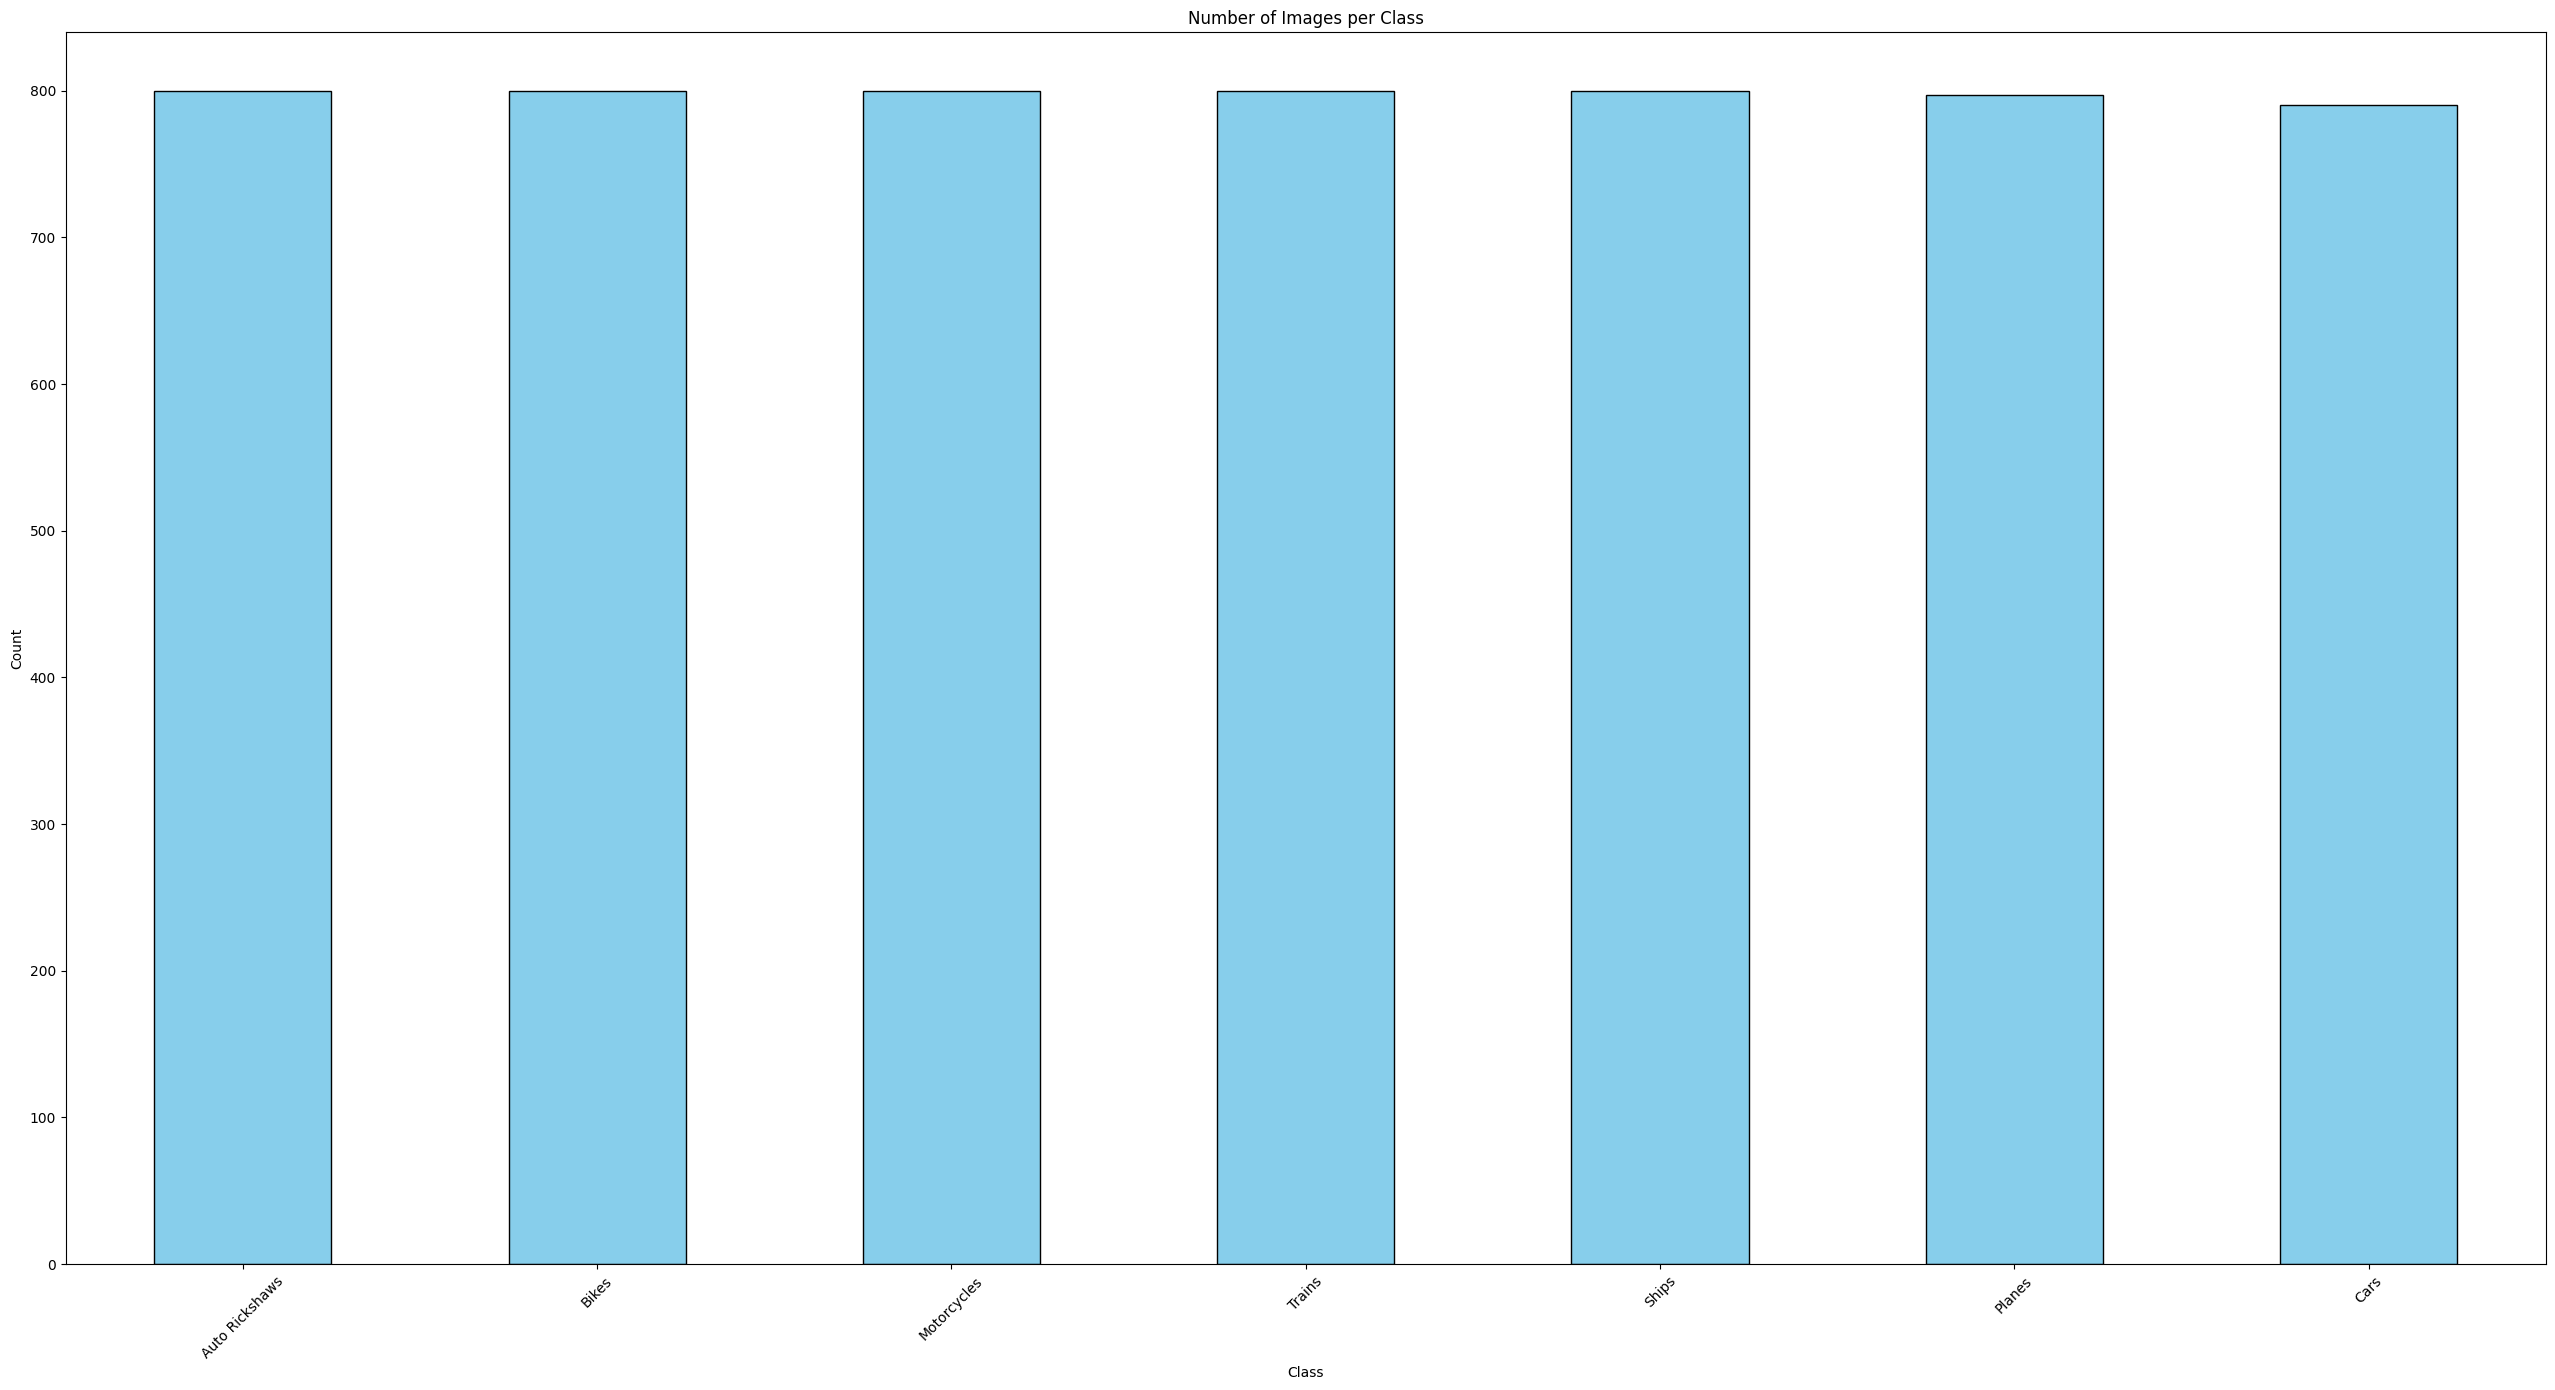

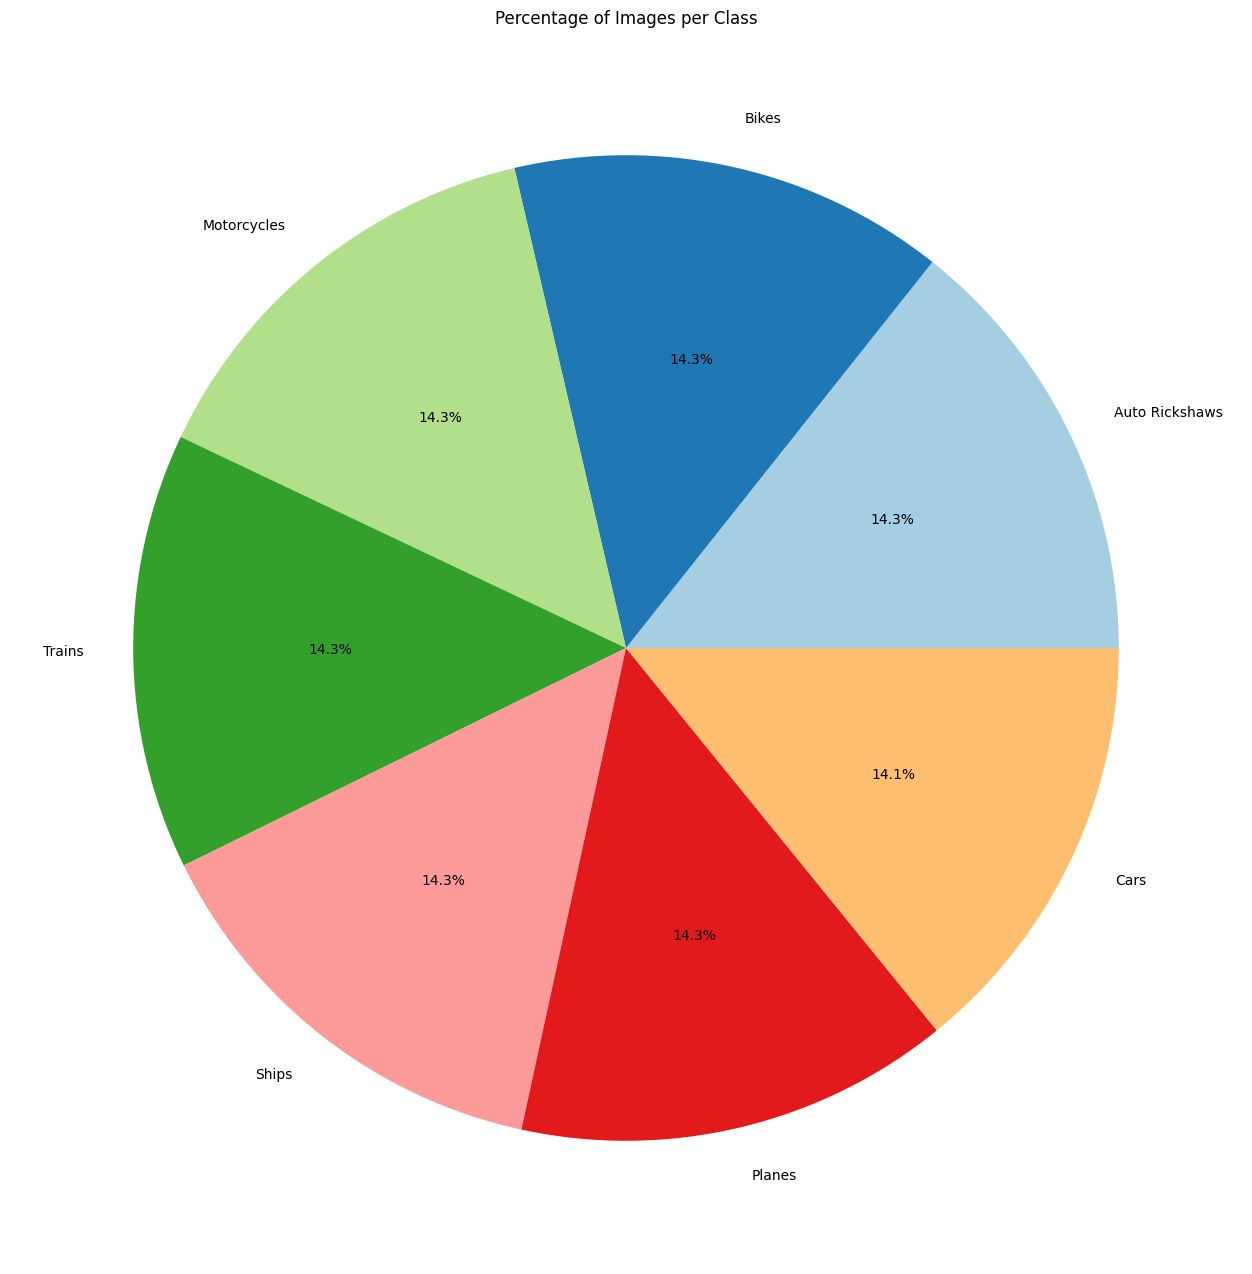

In [ ]:
plt.figure(figsize = (32, 16))
class_count.plot(kind = 'bar', color = 'skyblue', edgecolor = 'black')
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.show()

plt.figure(figsize = (32, 16))
class_count.plot(kind = 'pie', autopct = '%1.1f%%', colors = plt.cm.Paired.colors)
plt.title('Percentage of Images per Class')
plt.ylabel('')
plt.show()

                Count  Percentage %
class                              
Auto Rickshaws    800         14.32
Bikes             800         14.32
Motorcycles       800         14.32
Trains            800         14.32
Ships             800         14.32
Planes            797         14.27
Cars              790         14.14


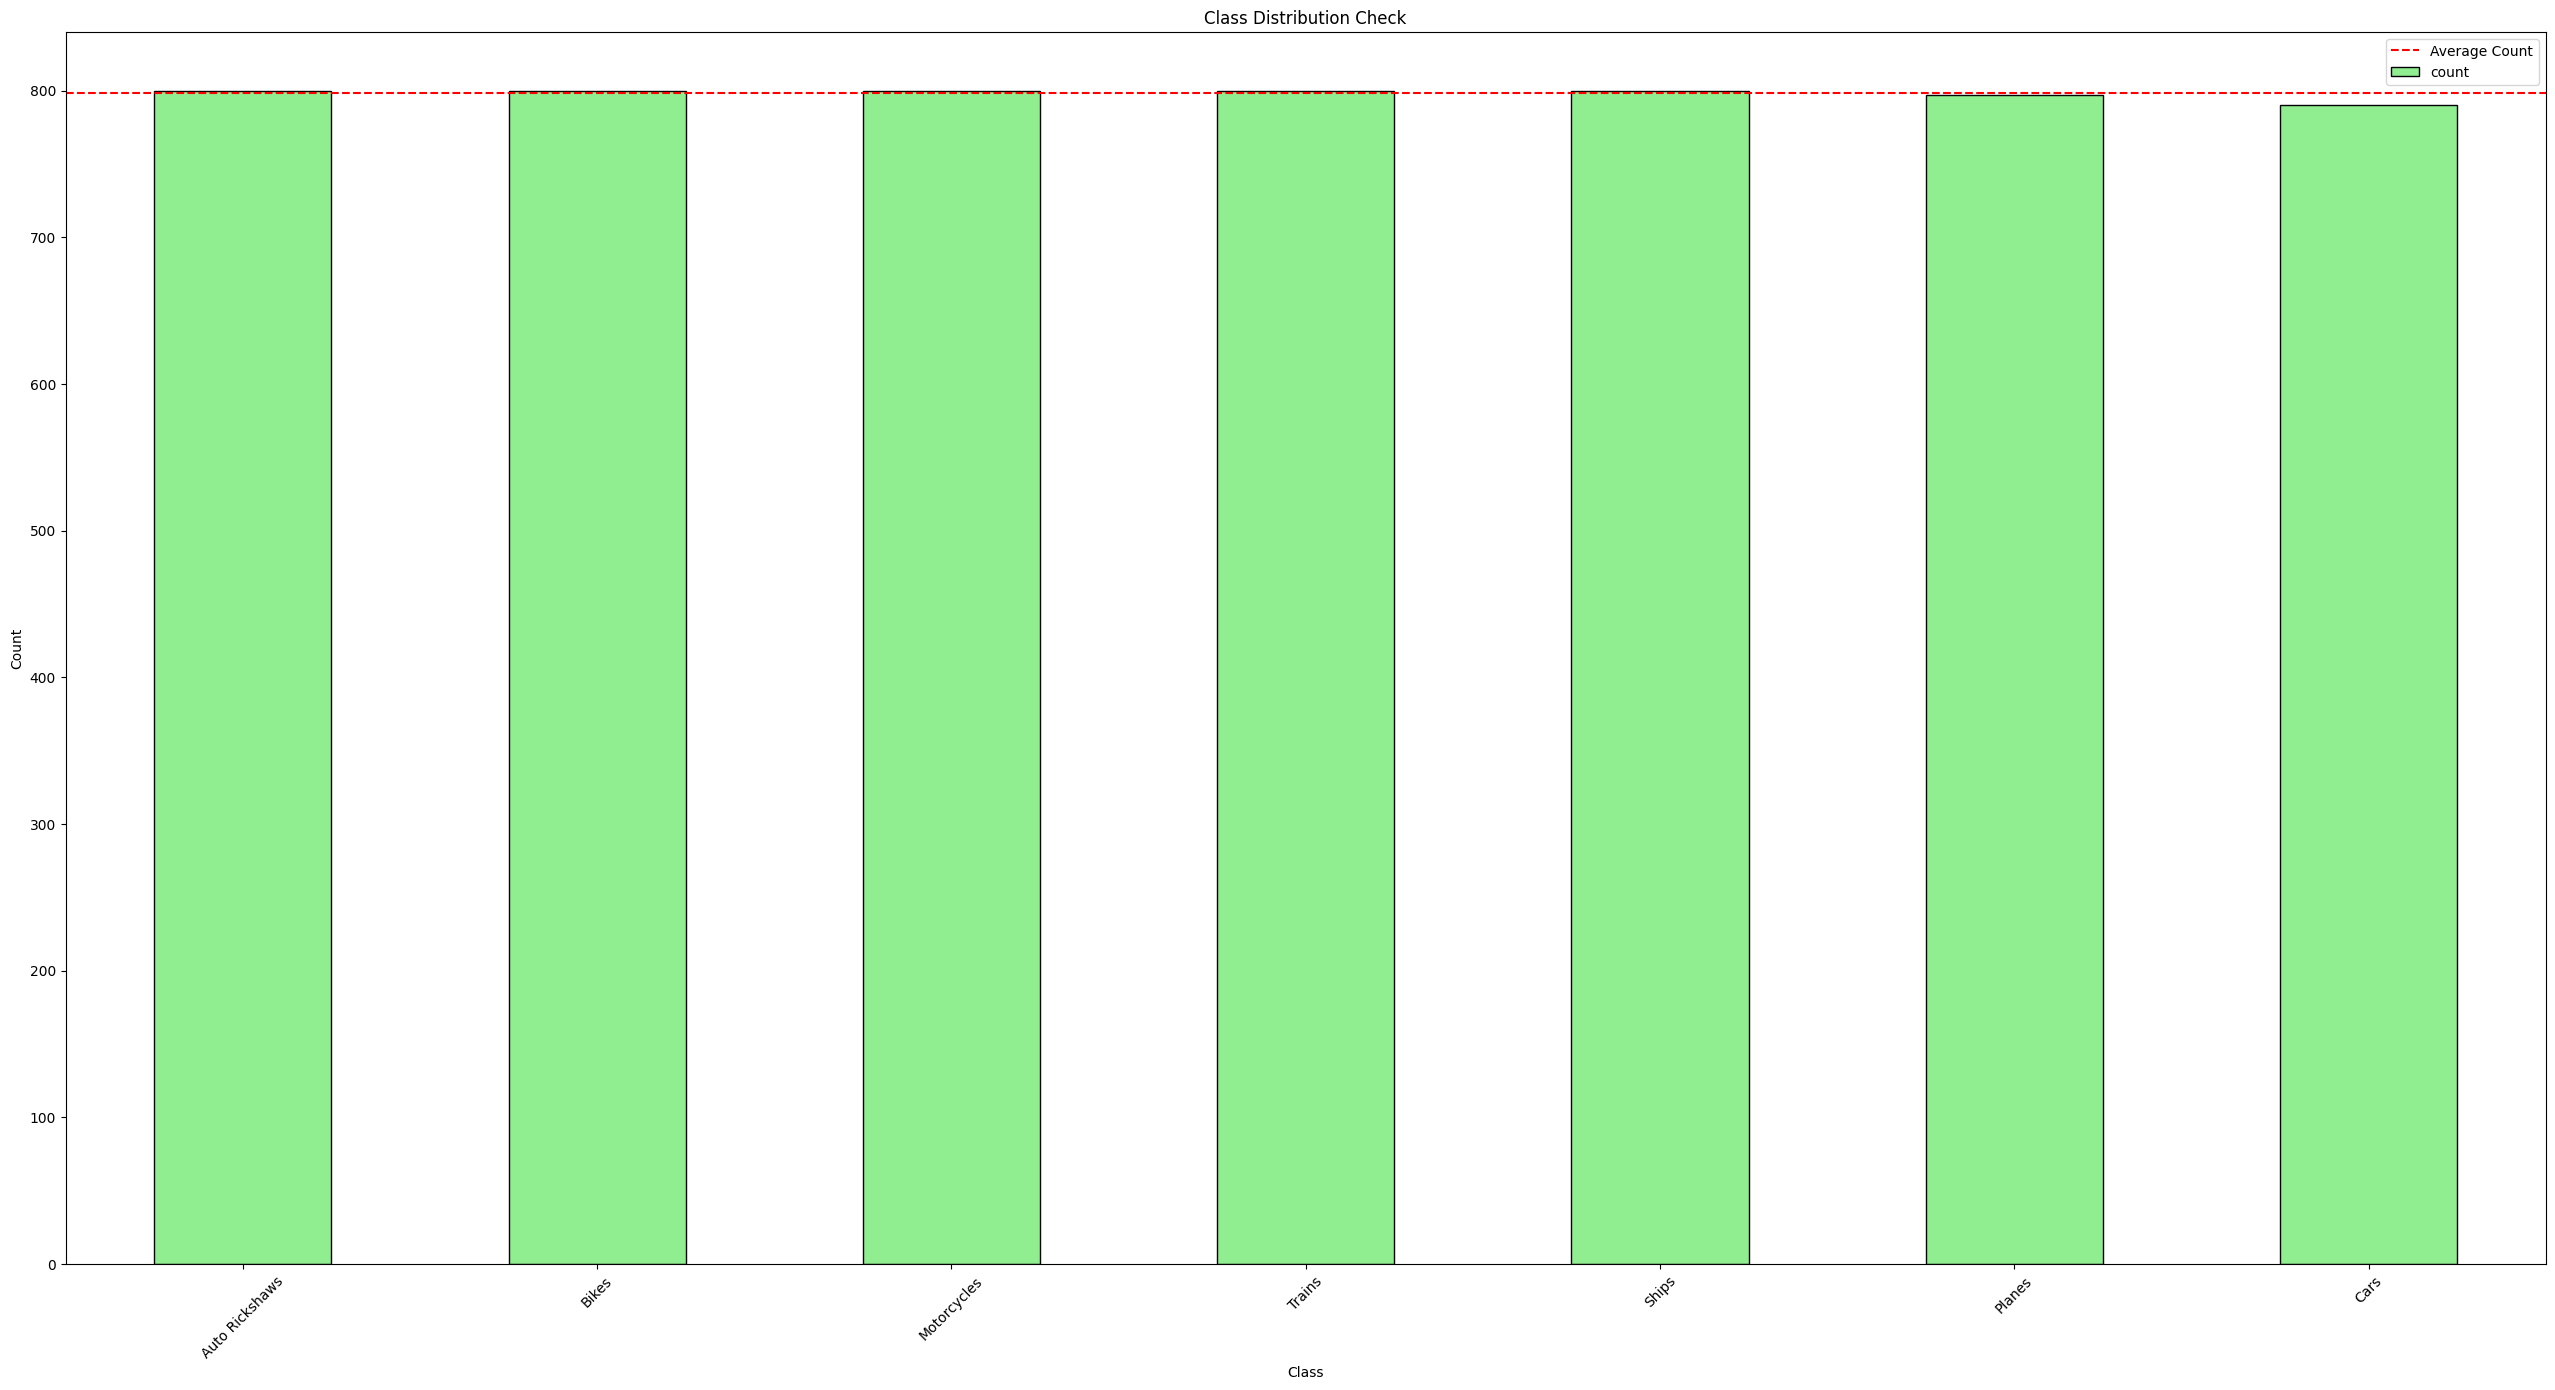

In [ ]:
percentages = (class_count / len(df)) * 100
imbalance_df = pd.DataFrame({'Count': class_count, 'Percentage %': percentages.round(2)})
print(imbalance_df)

plt.figure(figsize = (32, 16))
class_count.plot(kind = 'bar', color = 'lightgreen', edgecolor = 'black')
plt.title('Class Distribution Check')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.axhline(y = class_count.mean(), color = 'red', linestyle = '--', label = 'Average Count')
plt.legend()

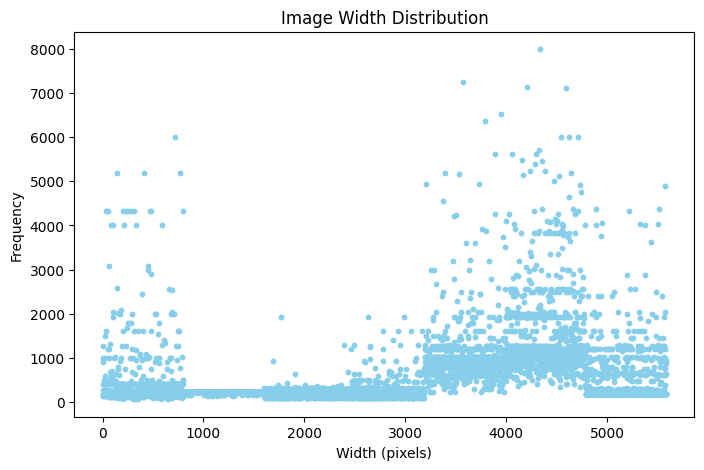

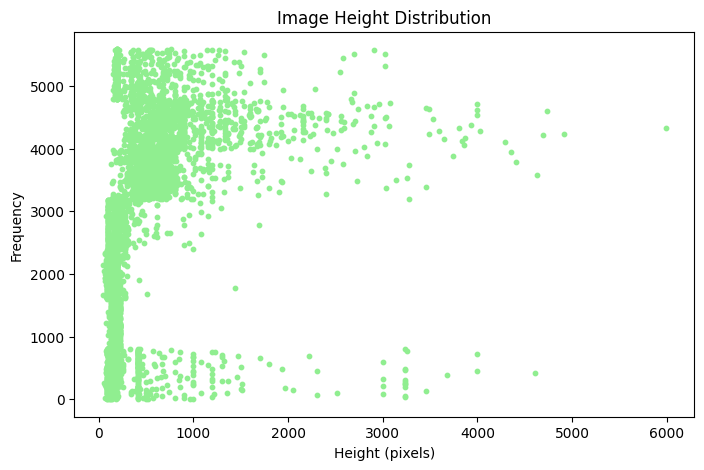

      Width  Height  Count
0       192     192    426
1       225     169    379
2       275     183    353
3       300     168    186
4       100     100    139
...     ...     ...    ...
1726    800     496      1
1727    800     494      1
1728    800     489      1
1729    800     488      1
1730    800     512      1

[1731 rows x 3 columns]
Image Mode Distribution:
Mode
RGB    5587
Name: count, dtype: int64

Number of Channels Distribution:
Channels
3    5587
Name: count, dtype: int64


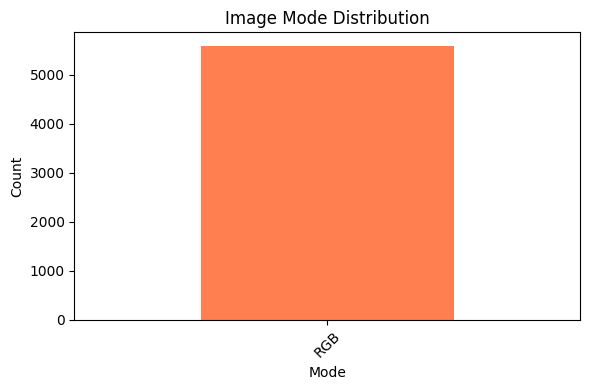

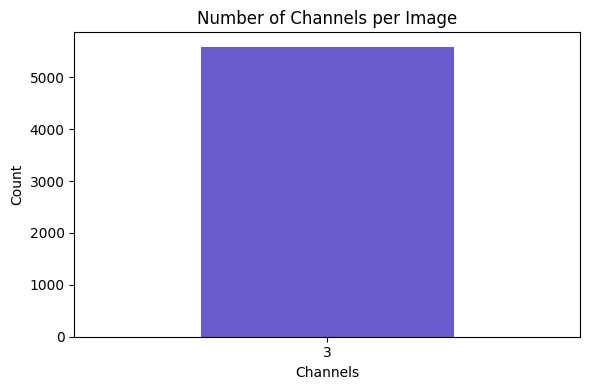

In [ ]:
image_sizes = []

for file_path in df['full_path']:
    with Image.open(file_path) as img:
        image_sizes.append(img.size)

sizes_df = pd.DataFrame(image_sizes, columns=['Width', 'Height'])

#Width
plt.figure(figsize=(8,5))
plt.scatter(x = range(len(sizes_df)), y = sizes_df['Width'], color='skyblue', s=10)
plt.title('Image Width Distribution')
plt.xlabel('Width (pixels)')
plt.ylabel('Frequency')
plt.show()

#Height
plt.figure(figsize=(8,5))
plt.scatter(x = sizes_df['Height'], y = range(len(sizes_df)), color='lightgreen', s=10)
plt.title('Image Height Distribution')
plt.xlabel('Height (pixels)')
plt.ylabel('Frequency')
plt.show()

#For best sure the size of the whole images
unique_sizes = sizes_df.value_counts().reset_index(name='Count')
print(unique_sizes)

image_data = []

for file_path in df['full_path']:
    with Image.open(file_path) as img:
        width, height = img.size
        mode = img.mode  # e.g., 'RGB', 'L', 'RGBA', etc.
        channels = len(img.getbands())  # Number of channels
        image_data.append((width, height, mode, channels))

# Create DataFrame
image_df = pd.DataFrame(image_data, columns=['Width', 'Height', 'Mode', 'Channels'])

print("Image Mode Distribution:")
print(image_df['Mode'].value_counts())

print("\nNumber of Channels Distribution:")
print(image_df['Channels'].value_counts())

plt.figure(figsize=(6,4))
image_df['Mode'].value_counts().plot(kind='bar', color='coral')
plt.title("Image Mode Distribution")
plt.xlabel("Mode")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
image_df['Channels'].value_counts().sort_index().plot(kind='bar', color='slateblue')
plt.title("Number of Channels per Image")
plt.xlabel("Channels")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Target directory for balanced dataset
balanced_dir = "/content/my_data_balanced"
os.makedirs(balanced_dir, exist_ok=True)

# Define augmentation generator
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

target_count = 800  # max per class

for cls in tqdm(df['class'].unique(), desc="Balancing classes"):
    class_df = df[df['class'] == cls]
    class_paths = class_df['full_path'].tolist()
    class_dir = os.path.join(balanced_dir, cls)
    os.makedirs(class_dir, exist_ok=True)

    # Copy originals first
    for path in class_paths:
        shutil.copy(path, class_dir)

    current_count = len(class_paths)
    if current_count >= target_count:
        continue

    num_to_generate = target_count - current_count
    gen_count = 0

    # Cycle through original images until we reach target_count
    while gen_count < num_to_generate:
        for img_path in class_paths:
            if gen_count >= num_to_generate:
                break

            img = load_img(img_path, target_size=(500, 500))
            x = img_to_array(img)
            x = np.expand_dims(x, axis=0)

            # Just one augmented version per image at a time
            batch = next(datagen.flow(x, batch_size=1))
            base_name = os.path.splitext(os.path.basename(img_path))[0]
            new_filename = f"aug_{base_name}_{uuid.uuid4().hex}.jpg"
            save_path = os.path.join(class_dir, new_filename)
            array_to_img(batch[0]).save(save_path)

            gen_count += 1

print("\nDataset balanced and saved at:", balanced_dir)

Balancing classes: 100%|██████████| 7/7 [00:07<00:00,  1.13s/it]


Dataset balanced and saved at: /content/my_data_balanced


In [ ]:
image_extensions = {'.jpg', '.jpeg', '.png'}
paths = [(path.parts[-2], path.name, str(path)) for path in Path(balanced_dir).rglob('*.*') if path.suffix.lower() in image_extensions]

df = pd.DataFrame(paths, columns = ['class', 'image', 'full_path'])
df = df.sort_values('class', ascending = True)
df.reset_index(drop = True, inplace = True)
df

,class,image,full_path
0,Auto Rickshaws,Auto Rickshaw (643).jpg,/content/my_data_balanced/Auto Rickshaws/Auto ...
1,Auto Rickshaws,Auto Rickshaw (432).jpg,/content/my_data_balanced/Auto Rickshaws/Auto ...
2,Auto Rickshaws,Auto Rickshaw (483).jpg,/content/my_data_balanced/Auto Rickshaws/Auto ...
3,Auto Rickshaws,Auto Rickshaw (144).jpg,/content/my_data_balanced/Auto Rickshaws/Auto ...
4,Auto Rickshaws,Auto Rickshaw (238).jpg,/content/my_data_balanced/Auto Rickshaws/Auto ...
...,...,...,...
5595,Trains,Train (191).jpg,/content/my_data_balanced/Trains/Train (191).jpg
5596,Trains,Train (438).jpg,/content/my_data_balanced/Trains/Train (438).jpg
5597,Trains,Train (430).jpg,/content/my_data_balanced/Trains/Train (430).jpg
5598,Trains,Train (429).jpg,/content/my_data_balanced/Trains/Train (429).jpg


In [ ]:
# Count per class
class_count = df['class'].value_counts()
for cls, count in class_count.items():
    print(f'Class: {cls}, Count: {count} images')

print(f"\nTotal dataset size is: {len(df)} images")
print(f"Number of classes: {df['class'].nunique()} classes")

extensions = [os.path.splitext(fname)[1].lower() for fname in df['image']]
ext_count = Counter(extensions)

print("\nImage format distribution:")
for ext, count in ext_count.items():
    print(f"Extension: {ext}, Count: {count} images")

Class: Auto Rickshaws, Count: 800 images
Class: Bikes, Count: 800 images
Class: Cars, Count: 800 images
Class: Motorcycles, Count: 800 images
Class: Planes, Count: 800 images
Class: Ships, Count: 800 images
Class: Trains, Count: 800 images

Total dataset size is: 5600 images
Number of classes: 7 classes

Image format distribution:
Extension: .jpg, Count: 5600 images


In [ ]:
# Pick a random class to visualize
random_class = random.choice(df['class'].unique())
class_df = df[df['class'] == random_class]

# Map originals to their augmentations
pairs = []
for orig_path in class_df[~class_df['image'].str.startswith("aug_")]['full_path']:
    base_name = os.path.splitext(os.path.basename(orig_path))[0]
    # Find all augmentations containing this base_name
    related_augs = class_df[class_df['image'].str.contains(f"aug_{base_name}")]['full_path'].tolist()
    if related_augs:
        pairs.append((orig_path, random.choice(related_augs)))  # pick one augmentation

# Pick up to 5 pairs
pairs = random.sample(pairs, min(5, len(pairs)))

plt.figure(figsize=(32, 16))
for i, (orig, aug) in enumerate(pairs):
    # Show original
    plt.subplot(len(pairs), 2, 2*i+1)
    plt.imshow(Image.open(orig).convert("RGB"))
    plt.title(f"{random_class} (Original)")
    plt.axis("off")

    # Show augmented
    plt.subplot(len(pairs), 2, 2*i+2)
    plt.imshow(Image.open(aug).convert("RGB"))
    plt.title(f"{random_class} (Augmented)")
    plt.axis("off")

plt.tight_layout()
plt.show()

<Figure size 3200x1600 with 0 Axes>

Image: Ship (527).jpg | Class: Ships | Size: 1111x340 | Brightness: 147.2 | Contrast: 65.8
Image: Ship (444).jpg | Class: Ships | Size: 910x1365 | Brightness: 122.2 | Contrast: 46.8
Image: Car (237).jpg | Class: Cars | Size: 162x65 | Brightness: 131.3 | Contrast: 49.4
Image: Motorcycle (181).jpg | Class: Motorcycles | Size: 286x176 | Brightness: 191.9 | Contrast: 91.4
Image: Motorcycle (433).jpg | Class: Motorcycles | Size: 300x168 | Brightness: 150.9 | Contrast: 61.1
Image: Ship (592).jpg | Class: Ships | Size: 1188x741 | Brightness: 154.2 | Contrast: 54.8
Image: Car (523).jpg | Class: Cars | Size: 183x275 | Brightness: 132.9 | Contrast: 81.0
Image: Car (481).jpg | Class: Cars | Size: 300x168 | Brightness: 150.6 | Contrast: 75.4
Image: Plane (659).jpg | Class: Planes | Size: 1024x683 | Brightness: 113.9 | Contrast: 62.2
Image: Bike (102).jpg | Class: Bikes | Size: 225x169 | Brightness: 150.6 | Contrast: 57.9


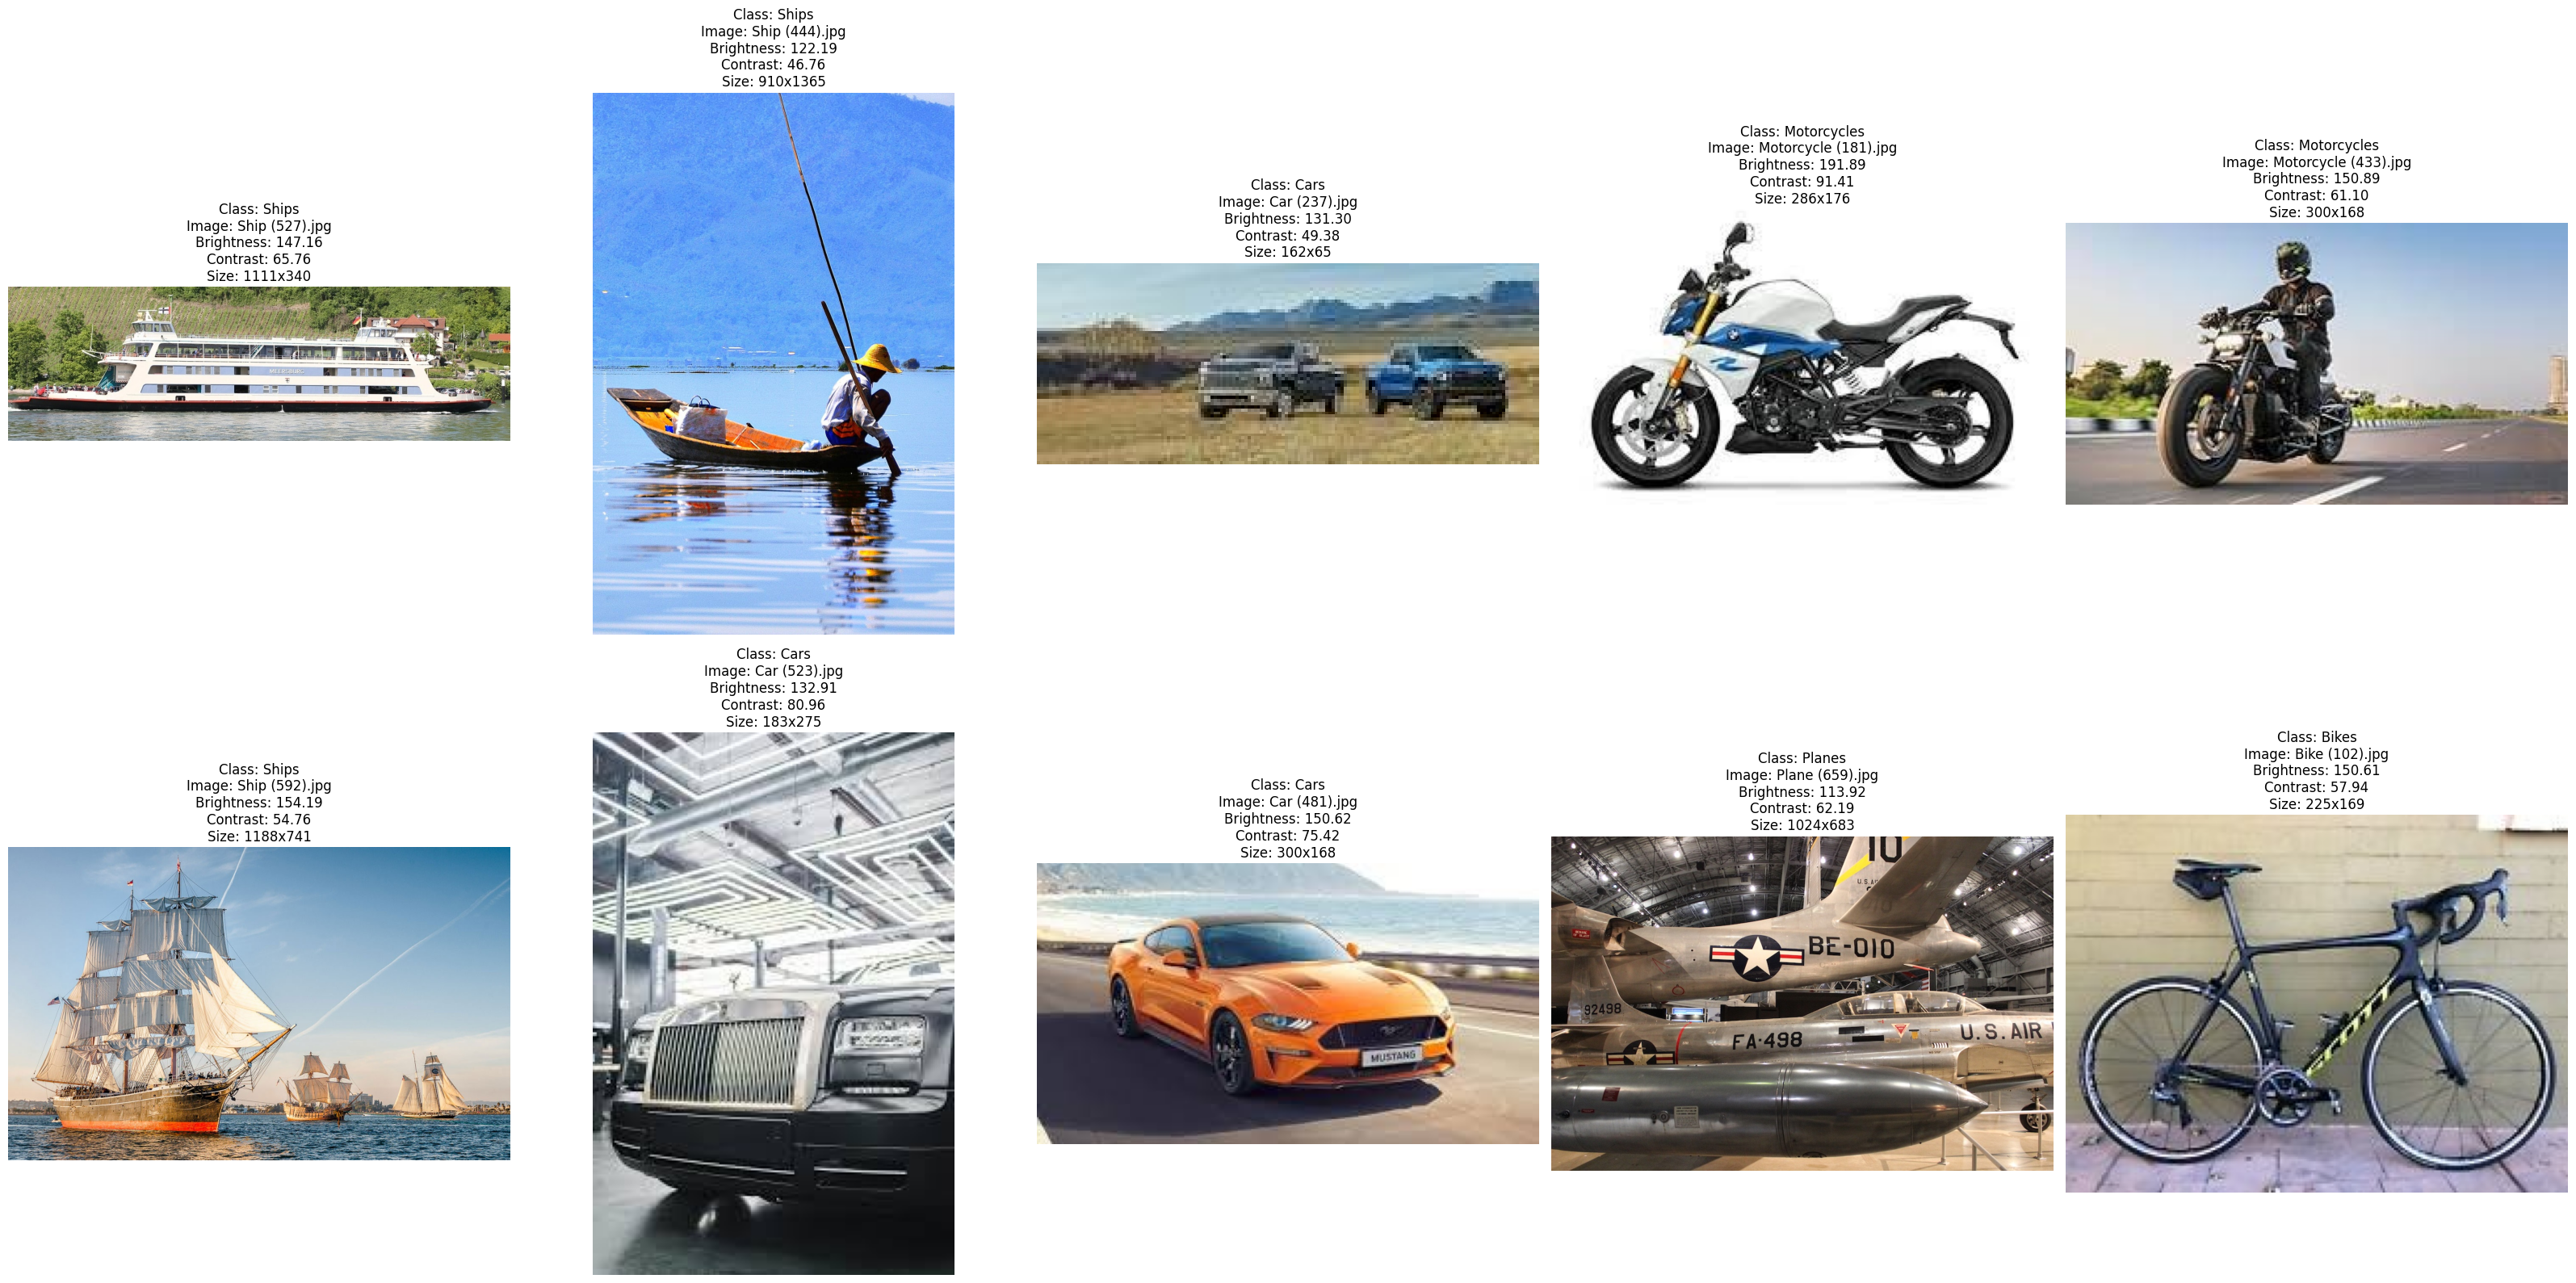

In [ ]:
sample_df = df.sample(n=10, random_state=42)

plt.figure(figsize=(32, 16))

for i, (cls, img_name, full_path) in enumerate(sample_df.values):
    with Image.open(full_path) as img:
        img_rgb = img.convert("RGB")   # always RGB for plotting

        stat = ImageStat.Stat(img_rgb)
        brightness = stat.mean[0]
        contrast = stat.stddev[0]

        width, height = img.size
        print(f"Image: {img_name} | Class: {cls} | Size: {width}x{height} | Brightness: {brightness:.1f} | Contrast: {contrast:.1f}")

        plt.subplot(2, 5, i + 1)
        plt.imshow(img_rgb)   # plot RGB version
        plt.axis('off')
        plt.title(
            f"Class: {cls}\n"
            f"Image: {img_name}\n"
            f"Brightness: {brightness:.2f}\n"
            f"Contrast: {contrast:.2f}\n"
            f"Size: {width}x{height}"
        )

plt.tight_layout()
plt.show()

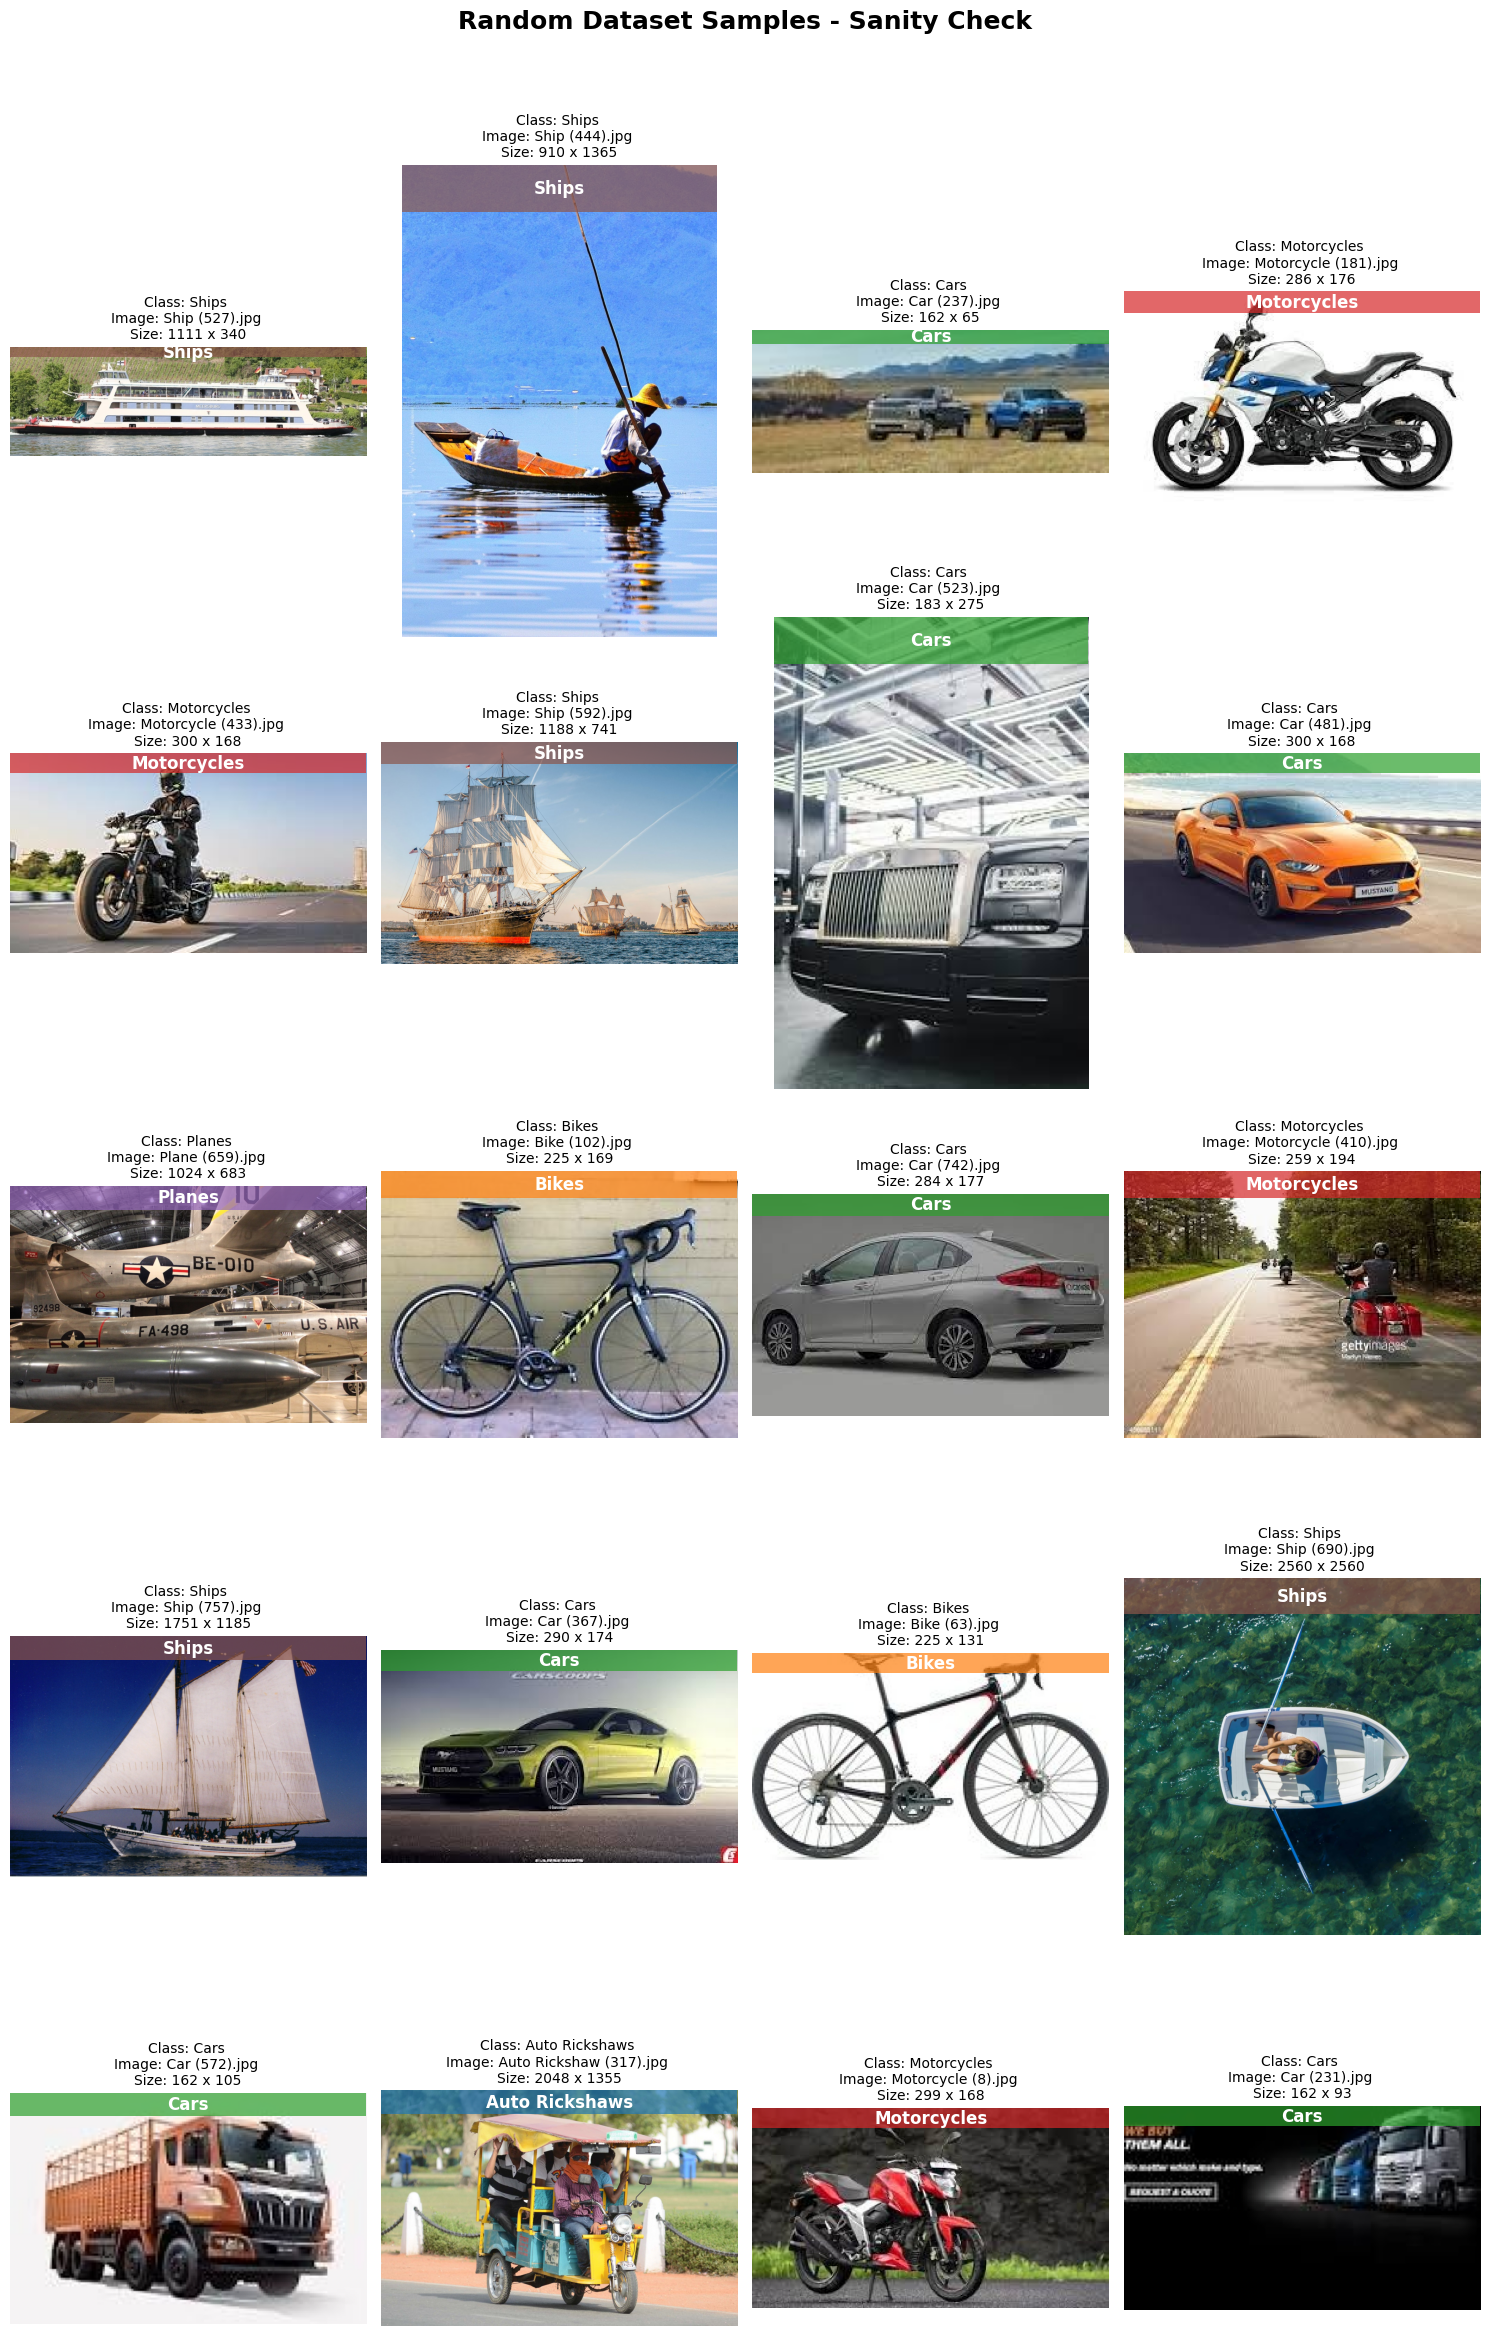

In [ ]:
# Sample 20 random images
num_samples = 20
sample_df = df.sample(num_samples, random_state=42)

# Get sorted class list and color map
classes = sorted(df['class'].unique())
colors = plt.cm.tab10.colors

# Grid setup
cols = 4
rows = num_samples // cols + int(num_samples % cols > 0)

# Figure setup
plt.figure(figsize=(15, 5 * rows))

for idx, (cls, img_name, full_path) in enumerate(sample_df.values):
    with Image.open(full_path) as img:
        img_rgb = img.convert("RGB")
        ax = plt.subplot(rows, cols, idx + 1)
        ax.imshow(img_rgb)
        ax.axis('off')

        # Title with class info
        ax.set_title(
            f"Class: {cls} \nImage: {img_name} \nSize: {img.width} x {img.height}",
            fontsize=10
        )

        # FIXED SIZE RECTANGLE IN AXES COORDINATES
        # Rectangle in axes coords: full width, small height at top
        label_height = 0.1  # 10% of image height
        label_width = 1.0   # full width of the image

        rect = patches.Rectangle(
        (0, 1 - label_height), label_width, label_height,
        transform=ax.transAxes,
        linewidth=0,
        edgecolor=None,
        facecolor=colors[classes.index(cls) % len(colors)],
        alpha=0.7
      )
        ax.add_patch(rect)

        # Add class name text centered horizontally
        ax.text(
        0.5, 1 - label_height / 2,
        cls,
        transform=ax.transAxes,
        fontsize=12,
        color="white",
        fontweight="bold",
        va="center",
        ha="center"
      )

# Figure title and layout
plt.suptitle("Random Dataset Samples - Sanity Check", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
#Check missing files
print("Missing values per column: ")
print(df.isnull().sum())

#Check duplicate files
duplicate_names = df.duplicated().sum()
print(f"\nNumber of duplicate files: {duplicate_names}")

duplicate_names = df[df.duplicated(subset = ['image'], keep = False)]
print(f"Duplicate file names: {len(duplicate_names)}")

#Check if two images or more are the same even if they are having different file names
def get_hash(file_path):
    with open(file_path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

df['file_hash'] = df['full_path'].apply(get_hash)
duplicate_hashes = df[df.duplicated(subset = ['file_hash'], keep = False)]
print(f"Duplicate image files: {len(duplicate_hashes)}")

#This code below just removing the duplicate files, which means will not be feeded to the model, but will be still in the actual directory
#Important note: duplicates are removed from the dataframe only, not from the actual directory.
#Drop duplicates based on file_hash, keeping the first one

# df_unique = df.drop_duplicates(subset='file_hash', keep='first')
# print(f"After removing duplicates, unique images: {len(df_unique)}")

#Check for images extentions
df['extenstion'] = df['image'].apply(lambda x: Path(x).suffix.lower())
print("File type counts: ")
#print(df['extenstion'].value_counts)
print(df['extenstion'].value_counts())

#Check for resolution relationships
df['Width'] = sizes_df['Width']
df['Height'] = sizes_df['Height']
#print(df.groupby(['Width', 'Height']).size())
print(df.groupby('class')[['Width', 'Height']].agg(['min', 'max', 'mean']))

#Check for class balance (relationship between label and count)
class_summary = df['class'].value_counts(normalize = False).to_frame('Count')
#class_summary['Percentage'] = class_summary['Count'] / class_summary['Count'].sum() * 100
#class_summary
class_summary['Percentage %'] = round((class_summary['Count'] / len(df)) * 100, 2)
print(class_summary)

Missing values per column: 
class        0
image        0
full_path    0
dtype: int64

Number of duplicate files: 0
Duplicate file names: 0
Duplicate image files: 279
File type counts: 
extenstion
.jpg    5600
Name: count, dtype: int64
                Width                     Height                     
                  min     max        mean    min     max         mean
class                                                                
Auto Rickshaws   63.0  6000.0   449.01875   59.0  4613.0   356.558750
Bikes           127.0   225.0   222.33250   75.0   225.0   164.195000
Cars             92.0  1920.0   231.59500   40.0  1440.0   155.833750
Motorcycles     100.0  1920.0   302.66375   81.0  1689.0   212.455000
Planes          219.0  7260.0  1046.67375  128.0  4630.0   669.441250
Ships           192.0  7993.0  1573.60750  154.0  5995.0  1035.795000
Trains          183.0  4889.0   541.05845  155.0  3024.0   389.933926
                Count  Percentage %
class                       

In [ ]:
# Check corrupted files
corrupted_files = []

for file_path in df['full_path']:
    try:
        with Image.open(file_path) as img:
            img.verify()  # Verify file integrity
    except (UnidentifiedImageError, OSError):
        corrupted_files.append(file_path)

print(f"Found {len(corrupted_files)} corrupted images.")

if corrupted_files:
    df = df[~df['full_path'].isin(corrupted_files)].reset_index(drop=True)
    print("Corrupted files removed.")


# Outliers detection (resolution-based)
width_mean = sizes_df['Width'].mean()
width_std = sizes_df['Width'].std()
height_mean = sizes_df['Height'].mean()
height_std = sizes_df['Height'].std()

outliers = df[
    (df['Width'] > width_mean + 3 * width_std) |
    (df['Width'] < width_mean - 3 * width_std) |
    (df['Height'] > height_mean + 3 * height_std) |
    (df['Height'] < height_mean - 3 * height_std)
]
print(f"Found {len(outliers)} resolution outliers.")

# Brightness / Contrast check (without storing images)
too_dark = []
too_bright = []
blank_or_gray = []

# Thresholds
dark_threshold = 30    # Below this is too dark
bright_threshold = 225 # Above this is too bright
low_contrast_threshold = 5  # Low contrast ~ blank/gray

for idx, file_path in enumerate(df['full_path']):
    try:
        with Image.open(file_path).convert('RGB') as img:
            gray = img.convert('L')
            stat = ImageStat.Stat(gray)
            brightness = stat.mean[0]
            contrast = stat.stddev[0]

            if brightness < dark_threshold:
                too_dark.append(file_path)
            elif brightness > bright_threshold:
                too_bright.append(file_path)
            elif contrast < low_contrast_threshold:
                blank_or_gray.append(file_path)
    except Exception as e:
        print(f"Skipping {file_path} due to error: {e}")

print(f"Too dark images: {len(too_dark)}")
print(f"Too bright images: {len(too_bright)}")
print(f"Blank/gray images: {len(blank_or_gray)}")

# (Optional) Drop too bright / blank-gray images
# df = df[~df['full_path'].isin(too_bright + blank_or_gray)].reset_index(drop=True)

# Note: No in-memory enhancement here.
# Enhancements (brightness/contrast adjustments) will be moved into `tf.data` pipeline.

Found 0 corrupted images.
Found 145 resolution outliers.
Too dark images: 14
Too bright images: 48
Blank/gray images: 0


In [ ]:
# Point to the extracted dataset, not the zip file location
dataset_root = "/content/my_data_balanced"

# Check mislabeled images
mismatches = []
for i, row in df.iterrows():
    folder_name = os.path.basename(os.path.dirname(row["full_path"]))
    if row["class"] != folder_name:
        mismatches.append((row["full_path"], row["class"], folder_name))

print(f"Found {len(mismatches)} mislabeled images (class vs folder mismatch).")

# Compare classes vs folders
classes_in_df = set(df["class"].unique())
folders_in_fs = {f for f in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root, f))}

print("Classes in DF but not in folders:", classes_in_df - folders_in_fs)
print("Folders in FS but not in DF:", folders_in_fs - classes_in_df)

Found 0 mislabeled images (class vs folder mismatch).
Classes in DF but not in folders: set()
Folders in FS but not in DF: set()


In [ ]:
def check_file_naming_issues(df):
    issues = {"invalid_chars": [], "spaces": [], "long_paths": [], "case_conflicts": [], "duplicate_names_across_classes": []}

    seen_names = {}

    for _, row in df.iterrows():
        fpath = row["full_path"]              # full path
        fname = os.path.basename(fpath)       # just filename
        cls = row["class"]

        # Invalid characters
        if re.search(r'[<>:"/\\|?*]', fname):  # Windows restricted chars
            issues["invalid_chars"].append(fpath)

        # Spaces
        if "  " in fname or fname.startswith(" ") or fname.endswith(" "):
            issues["spaces"].append(fpath)

        # Long paths
        if len(fpath) > 255:
            issues["long_paths"].append(fpath)

        # Case conflicts
        lower_name = fname.lower()
        if lower_name in seen_names and seen_names[lower_name] != cls:
            issues["case_conflicts"].append((fpath, seen_names[lower_name]))
        else:
            seen_names[lower_name] = cls

    # Duplicate names across classes
    duplicates = df.groupby(df["full_path"].apply(os.path.basename))["class"].nunique()
    duplicates = duplicates[duplicates > 1].index.tolist()
    for dup in duplicates:
        dup_paths = df[df["full_path"].str.endswith(dup)]["full_path"].tolist()
        issues["duplicate_names_across_classes"].extend(dup_paths)

    return issues

# Run the check
naming_issues = check_file_naming_issues(df)

for issue_type, files in naming_issues.items():
    print(f"\n{issue_type.upper()} ({len(files)})")
    for f in files[:10]:  # preview first 10
        print(f)


INVALID_CHARS (0)

SPACES (0)

LONG_PATHS (0)

CASE_CONFLICTS (0)

DUPLICATE_NAMES_ACROSS_CLASSES (0)


In [ ]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['class'])
print("Classes found:", le.classes_)

num_classes = len(le.classes_)
print("Number of classes:", num_classes)

Classes found: ['Auto Rickshaws' 'Bikes' 'Cars' 'Motorcycles' 'Planes' 'Ships' 'Trains']
Number of classes: 7


In [ ]:
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    df['full_path'], df['label_encoded'],
    test_size=0.1, random_state=42, stratify=df['label_encoded']
)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size=0.1, random_state=42, stratify=train_val_labels
)

In [ ]:
too_dark = set(map(str, too_dark))
too_bright = set(map(str, too_bright))

model = timm.create_model("xception", pretrained=True)

# Resolve preprocessing config automatically for this model
data_config = resolve_model_data_config(model)

# Create transformations directly from timm
train_transform = create_transform(**data_config, is_training=True)
val_transform   = create_transform(**data_config, is_training=False)

print(" Using timm preprocessing configuration:")
print(data_config)

# Custom Dataset
class ImageDataset(Dataset):
    def __init__(self, paths, labels, transform, augment=False):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform
        self.augment = augment

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]

        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Brightness correction
        if self.augment:
            if path in too_dark:
                img = cv2.convertScaleAbs(img, alpha=1.5, beta=30)
            elif path in too_bright:
                img = cv2.convertScaleAbs(img, alpha=0.9, beta=-30)

        # Convert to PIL for timm transforms
        img = Image.fromarray(img)

        img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
 Using timm preprocessing configuration:
{'input_size': (3, 299, 299), 'interpolation': 'bicubic', 'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'crop_pct': 0.8975, 'crop_mode': 'center'}


In [ ]:
# Data Loaders
batch_size = 32
train_ds = ImageDataset(train_paths, train_labels, transform=train_transform, augment=True)
val_ds   = ImageDataset(val_paths, val_labels, transform=val_transform, augment=False)
test_ds  = ImageDataset(test_paths, test_labels, transform=val_transform, augment=False)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# This can slightly speed up the training process during training or feeding up the data to the model
# train_loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True, prefetch_factor=2)

# Normalization Check
def check_normalization(dataloader, name):
    all_min, all_max = [], []
    for images, _ in dataloader:
        all_min.append(images.min().item())
        all_max.append(images.max().item())
    print(f"{name} dataset -> Min: {min(all_min):.4f}, Max: {max(all_max):.4f}")

check_normalization(train_loader, "Train")
check_normalization(val_loader, "Validation")
check_normalization(test_loader, "Test")

Train dataset -> Min: -1.0000, Max: 1.0000
Validation dataset -> Min: -1.0000, Max: 1.0000
Test dataset -> Min: -1.0000, Max: 1.0000


# **Train new classifier head only**

In [ ]:
# Load pretrained Xception backbone
model = timm.create_model("xception", pretrained=True)

# Freeze all convolutional layers (feature extractor)
for param in model.parameters():
    param.requires_grad = False

# Get number of input features for the classifier
in_features = model.get_classifier().in_features

# Replace the top (fc)
model.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)  # len(le.classes_)
)

# Move the model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# torch.compile should be after moving to device
model = torch.compile(model)

# Get a sample batch and infer input shape
sample, _ = next(iter(train_loader))
input_shape = sample.shape[1:]  # (3, H, W)
# print(model)
# Print model summary
summary(model, input_size=input_shape, device="cuda" if torch.cuda.is_available() else "cpu")

W1025 07:07:23.410000 670 torch/_inductor/utils.py:1436] [0/0] Not enough SMs to use max_autotune_gemm mode


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 149, 149]             864
       BatchNorm2d-2         [-1, 32, 149, 149]              64
              ReLU-3         [-1, 32, 149, 149]               0
            Conv2d-4         [-1, 64, 147, 147]          18,432
       BatchNorm2d-5         [-1, 64, 147, 147]             128
              ReLU-6         [-1, 64, 147, 147]               0
            Conv2d-7         [-1, 64, 147, 147]             576
            Conv2d-8        [-1, 128, 147, 147]           8,192
   SeparableConv2d-9        [-1, 128, 147, 147]               0
      BatchNorm2d-10        [-1, 128, 147, 147]             256
             ReLU-11        [-1, 128, 147, 147]               0
           Conv2d-12        [-1, 128, 147, 147]           1,152
           Conv2d-13        [-1, 128, 147, 147]          16,384
  SeparableConv2d-14        [-1, 128, 1

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-5)

In [ ]:
best_val_loss = float('inf')
patience = 10
trigger_times = 0

for epoch in range(15):  # same as your TensorFlow 15 epochs
    print(f"\nEpoch {epoch+1}/15")

    # Training
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(train_loader, desc="Training"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc="Validating"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            val_loss += criterion(outputs, labels).item()
            preds = torch.argmax(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model_phase1.pt")
        trigger_times = 0
        print("New best model saved")
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print("Early stopping.")
            break


Epoch 1/15


Validating: 100%|██████████| 16/16 [00:34<00:00,  2.13s/it]


Train Loss: 0.3674 | Train Acc: 0.8882 | Val Loss: 0.0465 | Val Acc: 0.9841
New best model saved

Epoch 2/15


Validating: 100%|██████████| 16/16 [00:11<00:00,  1.40it/s]


Train Loss: 0.2024 | Train Acc: 0.9361 | Val Loss: 0.0456 | Val Acc: 0.9861
New best model saved

Epoch 3/15


...

Train Loss: 0.1407 | Train Acc: 0.9524 | Val Loss: 0.0369 | Val Acc: 0.9901

Epoch 14/15


Validating: 100%|██████████| 16/16 [00:11<00:00,  1.36it/s]


Train Loss: 0.1515 | Train Acc: 0.9519 | Val Loss: 0.0237 | Val Acc: 0.9960

Epoch 15/15


Validating: 100%|██████████| 16/16 [00:11<00:00,  1.37it/s]

Train Loss: 0.1318 | Train Acc: 0.9533 | Val Loss: 0.0295 | Val Acc: 0.9901


# **Fine Tuning the Model**

In [ ]:
# Unfreeze last N layers for fine-tuning
for name, param in model.named_parameters():
    if any(block in name for block in ["conv4", "conv5", "block14", "fc"]):
        param.requires_grad = True
    else:
        param.requires_grad = False

In [ ]:
# Recreate optimizer with smaller LR
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

# Load best frozen model
model.load_state_dict(torch.load("best_model_phase1.pt"))

<All keys matched successfully>

In [ ]:
best_val_loss = float('inf')
trigger_times = 0
patience = 20

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(30):  # fine-tune phase
    print(f"\nFine-tuning Epoch {epoch+1}/30")

    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(train_loader, desc="Training"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc="Validating"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            val_loss += criterion(outputs, labels).item()
            preds = torch.argmax(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    scheduler.step(val_loss)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model_finetuned.pt")
        trigger_times = 0
        print("New best fine-tuned model saved!")
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print("Early stopping (fine-tuning).")
            break

model.load_state_dict(torch.load("best_model_finetuned.pt"))
print("\nFine-tuning complete — restored best fine-tuned model.")


Fine-tuning Epoch 1/30


Validating: 100%|██████████| 16/16 [00:12<00:00,  1.30it/s]


Train Loss: 0.1255 | Train Acc: 0.9605 | Val Loss: 0.0188 | Val Acc: 0.9940
New best fine-tuned model saved!

Fine-tuning Epoch 2/30


Validating: 100%|██████████| 16/16 [00:11<00:00,  1.38it/s]


Train Loss: 0.1264 | Train Acc: 0.9552 | Val Loss: 0.0188 | Val Acc: 0.9940

Fine-tuning Epoch 3/30


...

Train Loss: 0.1062 | Train Acc: 0.9638 | Val Loss: 0.0179 | Val Acc: 0.9960

Fine-tuning Epoch 29/30


Validating: 100%|██████████| 16/16 [00:11<00:00,  1.35it/s]


Train Loss: 0.1186 | Train Acc: 0.9572 | Val Loss: 0.0191 | Val Acc: 0.9960

Fine-tuning Epoch 30/30


Validating: 100%|██████████| 16/16 [00:11<00:00,  1.39it/s]


Train Loss: 0.1273 | Train Acc: 0.9592 | Val Loss: 0.0198 | Val Acc: 0.9960

Fine-tuning complete — restored best fine-tuned model.


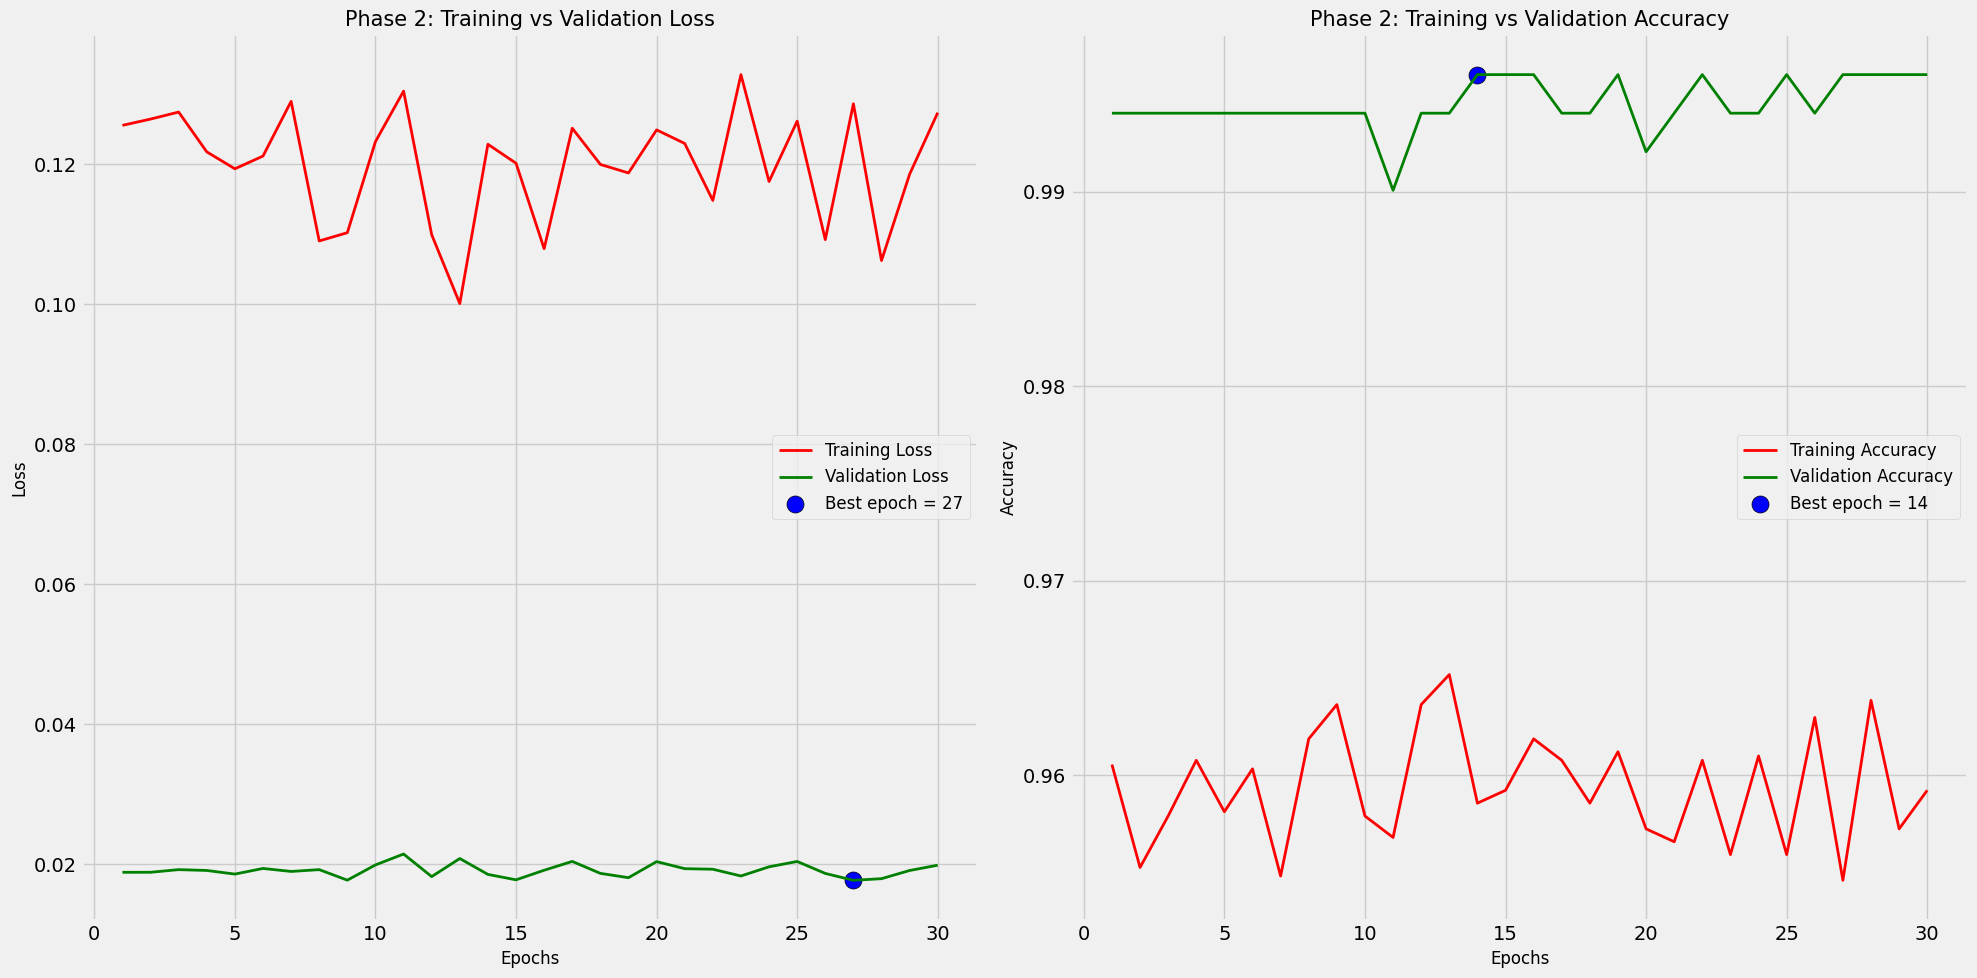

In [ ]:
# Phase 2 Evaluation
tr_acc = train_accuracies
tr_loss = train_losses
val_acc = val_accuracies
val_loss = val_losses

# Best (lowest) validation loss and highest validation accuracy
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {index_loss + 1}'
acc_label = f'Best epoch = {index_acc + 1}'

plt.figure(figsize=(20, 10))
plt.style.use('fivethirtyeight')

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', linewidth=2, label='Training Loss')
plt.plot(Epochs, val_loss, 'g', linewidth=2, label='Validation Loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label, edgecolor='black')
plt.title('Phase 2: Training vs Validation Loss', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', linewidth=2, label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', linewidth=2, label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label, edgecolor='black')
plt.title('Phase 2: Training vs Validation Accuracy', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

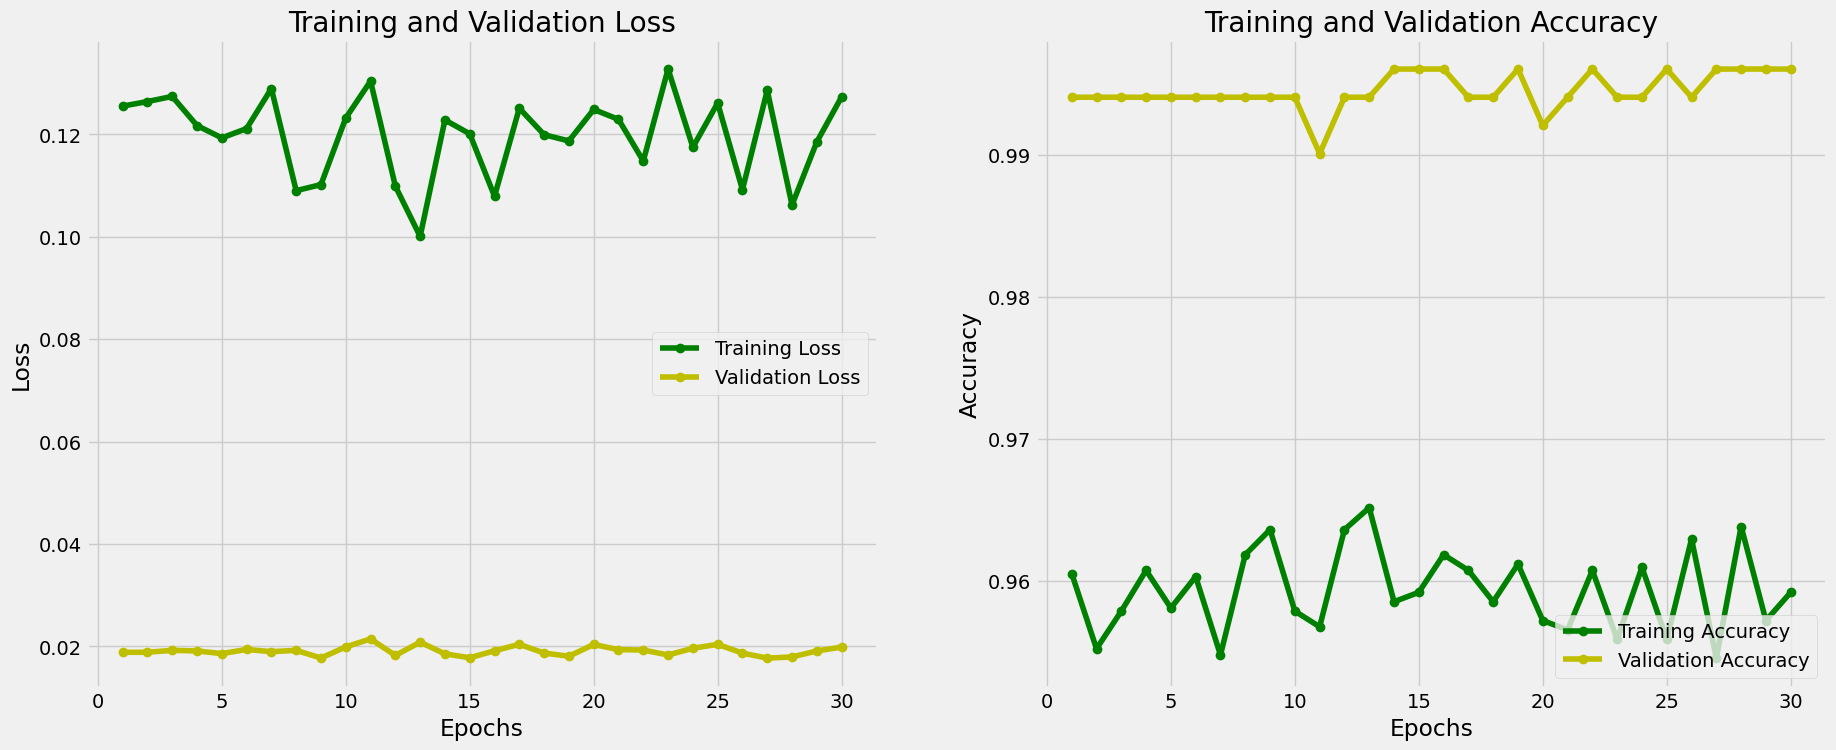

In [ ]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(20, 8)

# Use tracked lists instead of history.history
train_acc = train_accuracies
train_loss = train_losses
val_acc = val_accuracies
val_loss = val_losses

epochs = range(1, len(train_acc) + 1)

# Loss plot
ax[0].plot(epochs, train_loss, 'g-o', label='Training Loss')
ax[0].plot(epochs, val_loss, 'y-o', label='Validation Loss')
ax[0].set_title('Training and Validation Loss')
ax[0].legend()
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')

# Accuracy plot
ax[1].plot(epochs, train_acc, 'g-o', label='Training Accuracy')
ax[1].plot(epochs, val_acc, 'y-o', label='Validation Accuracy')
ax[1].set_title('Training and Validation Accuracy')
ax[1].legend(loc='lower right')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')

plt.show()

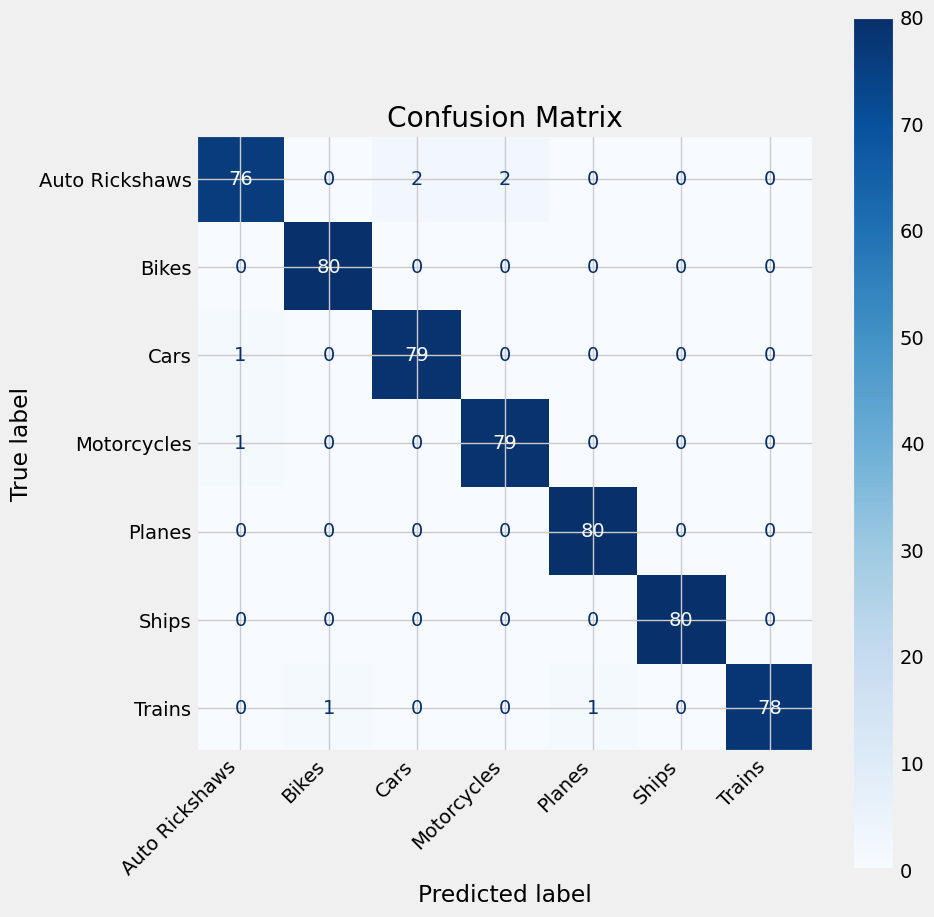

In [ ]:
# Put the model in evaluation mode
model.eval()

true_labels = []
pred_labels = []

# Disable gradient computation for evaluation
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(preds.cpu().numpy())

# Compute the confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Create a figure and axes to control the size
fig, ax = plt.subplots(figsize=(10, 10))  # Increase the size as needed

# Create and plot the confusion matrix display
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
cm_display.plot(cmap='Blues', values_format='d', ax=ax)

# Rotate x-axis labels to prevent overlap
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Adjust layout to avoid label clipping
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate on test dataset
model.eval()
test_loss = 0.0
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing", leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        correct += (preds == labels).sum().item()
        total += labels.size(0)

avg_test_loss = test_loss / len(test_loader)
test_accuracy = correct / total

print(f"\nTest Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Metrics
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

# Detailed report per class
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))


Test Loss: 0.0330
Test Accuracy: 0.9857
Precision: 0.9858, Recall: 0.9857, F1-score: 0.9857

Classification Report:
                precision    recall  f1-score   support

Auto Rickshaws       0.97      0.95      0.96        80
         Bikes       0.99      1.00      0.99        80
          Cars       0.98      0.99      0.98        80
   Motorcycles       0.98      0.99      0.98        80
        Planes       0.99      1.00      0.99        80
         Ships       1.00      1.00      1.00        80
        Trains       1.00      0.97      0.99        80

      accuracy                           0.99       560
     macro avg       0.99      0.99      0.99       560
  weighted avg       0.99      0.99      0.99       560



In [ ]:
model.eval()
test_loss = 0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        correct += (preds == labels).sum().item()
        total += labels.size(0)

avg_test_loss = test_loss / len(test_loader)
test_accuracy = correct / total

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Metrics
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

# Detailed report per class
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

Test Loss: 0.0330
Test Accuracy: 0.9857
Precision: 0.9858, Recall: 0.9857, F1-score: 0.9857

Classification Report:
                precision    recall  f1-score   support

Auto Rickshaws       0.97      0.95      0.96        80
         Bikes       0.99      1.00      0.99        80
          Cars       0.98      0.99      0.98        80
   Motorcycles       0.98      0.99      0.98        80
        Planes       0.99      1.00      0.99        80
         Ships       1.00      1.00      1.00        80
        Trains       1.00      0.97      0.99        80

      accuracy                           0.99       560
     macro avg       0.99      0.99      0.99       560
  weighted avg       0.99      0.99      0.99       560



In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)  # get probabilities
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

# Metrics per class
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, labels=np.arange(len(le.classes_))
)

df_metrics = pd.DataFrame({
    'Class': le.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1,
    'Support': support
})

# Sort by F1-score ascending
df_metrics_sorted = df_metrics.sort_values(by='F1-score')
print(df_metrics_sorted)

# Macro averages
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)

print(f"\nMacro Avg -> Precision: {precision_macro:.4f}, Recall: {recall_macro:.4f}, F1-score: {f1_macro:.4f}")

            Class  Precision  Recall  F1-score  Support
0  Auto Rickshaws   0.974359  0.9500  0.962025       80
2            Cars   0.975309  0.9875  0.981366       80
3     Motorcycles   0.975309  0.9875  0.981366       80
6          Trains   1.000000  0.9750  0.987342       80
1           Bikes   0.987654  1.0000  0.993789       80
4          Planes   0.987654  1.0000  0.993789       80
5           Ships   1.000000  1.0000  1.000000       80

Macro Avg -> Precision: 0.9858, Recall: 0.9857, F1-score: 0.9857


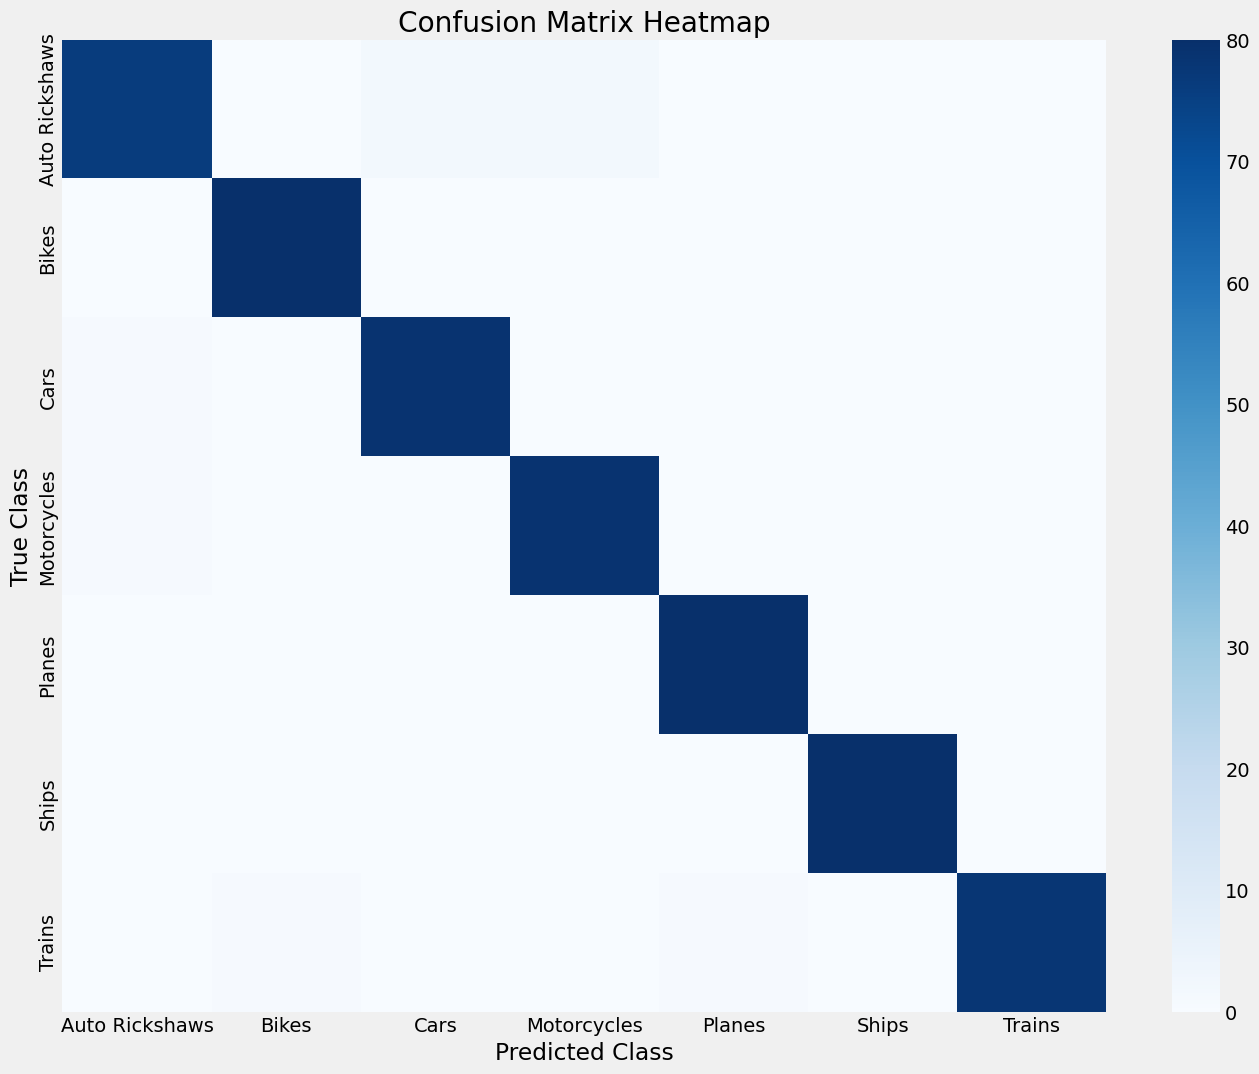

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(
    cm,
    annot=False,        # no numbers inside cells
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix Heatmap")
plt.show()

Precision: 0.9858, Recall: 0.9857, F1-score: 0.9857

Classification Report:
                precision    recall  f1-score   support

Auto Rickshaws       0.97      0.95      0.96        80
         Bikes       0.99      1.00      0.99        80
          Cars       0.98      0.99      0.98        80
   Motorcycles       0.98      0.99      0.98        80
        Planes       0.99      1.00      0.99        80
         Ships       1.00      1.00      1.00        80
        Trains       1.00      0.97      0.99        80

      accuracy                           0.99       560
     macro avg       0.99      0.99      0.99       560
  weighted avg       0.99      0.99      0.99       560



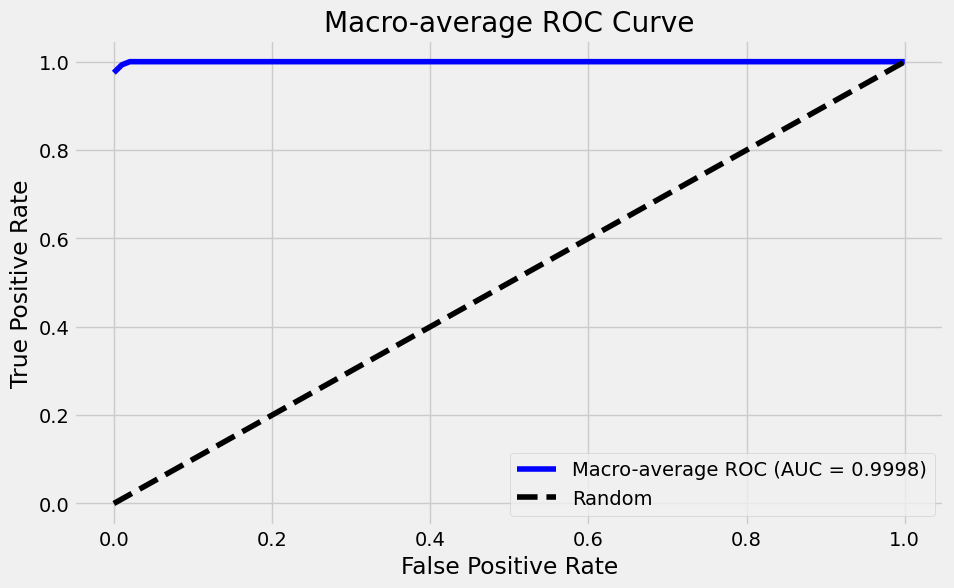

In [ ]:
model.eval()
test_loss = 0
correct = 0
total = 0

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing", leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)  # get class probabilities
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

# Convert lists to NumPy arrays
y_probs = np.concatenate(all_probs, axis=0)
y_true = np.concatenate(all_labels, axis=0)

# Predictions from probabilities
y_pred = np.argmax(y_probs, axis=1)

# Metrics
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

y_test_bin = label_binarize(y_true, classes=np.arange(len(le.classes_)))

all_fpr = np.linspace(0, 1, 100)
mean_tpr = 0

for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    mean_tpr += np.interp(all_fpr, fpr, tpr)

mean_tpr /= len(le.classes_)
roc_auc = auc(all_fpr, mean_tpr)

plt.figure(figsize=(10, 6))
plt.plot(all_fpr, mean_tpr, color='b', label=f'Macro-average ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-average ROC Curve')
plt.legend()
plt.show()

In [ ]:
model.load_state_dict(torch.load("best_model.pt"))  # restore best weights
torch.save(model.state_dict(), "cnn_model_weights.pth")
files.download("cnn_model_weights.pth")

# If you want to save a production-optimized version:
# Load best weights
# model.load_state_dict(torch.load("best_model.pt", map_location=device))
# model.eval()

# # Convert to TorchScript
# scripted_model = torch.jit.script(model)
# scripted_model.save("cnn_model_scripted.pt")
# print("TorchScript model saved for deployment.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save entire model
torch.save(model, "best_model_finetuned_full.pt")

In [ ]:
files.download("best_model_finetuned_full.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>